# Multiscale Ablation: Does SACP+GeoCP help more at smaller study-area scales?

**Single experiment, self-contained notebook**. Runs the multiscale ablation on 10 pre-downloaded Sentinel-2 tiles (no GEE pull, no Earth Engine auth required).

**Prerequisite**: `lubbock_tx.npz`, `polk_iowa.npz`, ..., `mississippi_la.npz` must exist in

```
/content/drive/MyDrive/sentinel2_landcover_pilot_10m/tiles/
```

These were produced by the Sentinel-2 pipeline of an earlier notebook and should already be on your Drive.

**What this notebook does**: for each of the 10 tiles, take the centre $S \times S$ patch at 4 different sizes ($S \in \{50, 100, 200, 500\}$ px, i.e. 0.5 – 5 km at 10 m/pixel), run the full `XGBoost → APS → SACP smoothing → {Standard CP, SACP, SACP+GeoCP}` pipeline, and report marginal coverage, set size, and interval score for each.

**Methodology**:
- Same tile center, same classifier architecture, same random seed across sizes — only the spatial extent varies (single-variable ablation)
- SACP+GeoCP bandwidth is selected via **5-fold CV on the calibration subsample** — the test set is used once per $(tile, size)$ to report final metrics
- Cal is capped at 20 000 (stratified) for $S = 500$ px to keep the distance matrix tractable

**Runtime**: ~30–40 minutes on a free Colab CPU instance.

## 1. Install dependencies

In [1]:
!pip install --quiet xgboost scikit-learn pandas matplotlib numpy scipy
!pip install --quiet git+https://github.com/pengtum/GeoCP_RS.git

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


## 2. Mount Drive and verify that the tiles are in place

This cell mounts Drive, resolves path constants, creates an output folder, and verifies that all 10 expected `.npz` tile files exist. It **does not** do any GEE pull — the data should already be on Drive.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

import os

# --- Path constants (pointing at existing Sentinel-2 tile data) ---
WORK_DIR    = '/content/drive/MyDrive/sentinel2_landcover_pilot_10m'
TILE_DIR    = f'{WORK_DIR}/tiles'
# Experiment outputs go to a subfolder so they don't clash with existing figures
RESULTS_DIR = f'{WORK_DIR}/multiscale'
FIG_DIR     = f'{RESULTS_DIR}/figures'
os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)

if not os.path.isdir(TILE_DIR):
    raise RuntimeError(
        f'TILE_DIR not found: {TILE_DIR}\n'
        f'Make sure your earlier Sentinel-2 pipeline wrote tiles to this path.')

expected_tiles = [
    'polk_iowa', 'lancaster_pa', 'hartford_ct', 'everglades_fl',
    'lubbock_tx', 'sacramento_ca', 'phoenix_az', 'yellowstone_wy',
    'seattle_wa', 'mississippi_la',
]

present = sorted([f.replace('.npz', '') for f in os.listdir(TILE_DIR) if f.endswith('.npz')])
missing = [t for t in expected_tiles if t not in present]

print(f'TILE_DIR    : {TILE_DIR}')
print(f'RESULTS_DIR : {RESULTS_DIR}')
print(f'FIG_DIR     : {FIG_DIR}')
print()
print(f'Found {len(present)} tile .npz files:')
for t in present:
    size_mb = os.path.getsize(f'{TILE_DIR}/{t}.npz') / 1024 / 1024
    marker = '✓' if t in expected_tiles else '?'
    print(f'  {marker} {t}: {size_mb:.1f} MB')
if missing:
    print(f'\nMISSING {len(missing)} expected tiles: {missing}')
    raise RuntimeError('Cannot proceed without all 10 tiles.')
print('\nAll 10 expected tiles are present. ✓')

Mounted at /content/drive
TILE_DIR    : /content/drive/MyDrive/sentinel2_landcover_pilot_10m/tiles
RESULTS_DIR : /content/drive/MyDrive/sentinel2_landcover_pilot_10m/multiscale
FIG_DIR     : /content/drive/MyDrive/sentinel2_landcover_pilot_10m/multiscale/figures

Found 10 tile .npz files:
  ✓ everglades_fl: 48.7 MB
  ✓ hartford_ct: 44.2 MB
  ✓ lancaster_pa: 45.4 MB
  ✓ lubbock_tx: 62.7 MB
  ✓ mississippi_la: 47.1 MB
  ✓ phoenix_az: 49.1 MB
  ✓ polk_iowa: 44.0 MB
  ✓ sacramento_ca: 45.5 MB
  ✓ seattle_wa: 38.7 MB
  ✓ yellowstone_wy: 40.1 MB

All 10 expected tiles are present. ✓


## 3. Tiles and experiment parameters

The 10 tiles are the same as in the Sentinel-2 land-cover pilot. Only their `tile_key` is needed here (for labelling and the lookup loop) — the bboxes are no longer required since we read from the cached `.npz` files directly.

In [3]:
# Tiles just need a key and a human-readable name — the geographic bbox is irrelevant
# at this stage because the .npz files are already on Drive with their own embedded grid.
TILES = {
    'polk_iowa':      'Polk County, Iowa (row-crop)',
    'lancaster_pa':   'Lancaster, Pennsylvania (mixed ag)',
    'hartford_ct':    'Hartford, Connecticut (urban-forest)',
    'everglades_fl':  'Everglades, Florida (wetland)',
    'lubbock_tx':     'Lubbock, Texas (irrigated dryland)',
    'sacramento_ca':  'Sacramento Delta, California',
    'phoenix_az':     'Phoenix, Arizona (desert-urban)',
    'yellowstone_wy': 'Yellowstone, Wyoming (forest)',
    'seattle_wa':     'Seattle, Washington (urban-water)',
    'mississippi_la': 'Mississippi Delta, Louisiana',
}

MSC_SIZES    = [50, 100, 200, 500]           # 0.5, 1, 2, 5 km at 10 m/px
MSC_BWGRID   = [3, 5, 10, 20, 50, 100]       # candidate bandwidths (pixels)
MSC_MAX_CAL  = 20000                          # cap cal subsample for tractability
MSC_CV_FOLDS = 5                              # CV for bandwidth selection
ALPHA        = 0.1                            # target miscoverage (target coverage 1 - α = 0.90)
LMD          = 0.5                            # SACP smoothing weight (paper default)
SEED         = 0                              # random seed for reproducibility

print(f'{len(TILES)} tiles × {len(MSC_SIZES)} sizes = {len(TILES) * len(MSC_SIZES)} experiments total')
print(f'Sizes: {MSC_SIZES} px = {[s*0.01 for s in MSC_SIZES]} km')
print(f'BW grid: {MSC_BWGRID} px (filtered per size)')
print(f'CV folds for bw selection: {MSC_CV_FOLDS}')
print(f'Cal subsample cap: {MSC_MAX_CAL}')

10 tiles × 4 sizes = 40 experiments total
Sizes: [50, 100, 200, 500] px = [0.5, 1.0, 2.0, 5.0] km
BW grid: [3, 5, 10, 20, 50, 100] px (filtered per size)
CV folds for bw selection: 5
Cal subsample cap: 20000


## 4. Helper functions and the per-patch pipeline

`run_pipeline_on_patch` takes a spatial slice of an existing tile and runs the complete CP procedure on it:

1. Filter rare classes (adaptive `min_count` depending on patch size)
2. Stratified 60 / 20 / 20 train / cal / test split
3. Train an XGBoost classifier (200 trees, `tree_method='hist'`)
4. Compute APS non-conformity scores; SACP smooth them on the full patch grid
5. Evaluate three CP methods: Standard CP, SACP (global threshold), SACP+GeoCP
6. **GeoCP bandwidth is chosen by 5-fold CV on the calibration subsample**; the test set is used exactly once at the selected bandwidth

In [4]:
import os, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb
from collections import Counter
from sklearn.model_selection import train_test_split, KFold
from scipy.spatial.distance import cdist
from scipy.signal import convolve2d

from geocp_rs.core import aps_scores, conformal_quantile, weighted_quantile
from geocp_rs.sacp import sacp_smooth
from geocp_rs.metrics import coverage_and_size, interval_score

def _morans_I_sparse(values_at_idx, flat_idx, H, W):
    '''8-neighbour Moran\'s I on an H×W grid where only a subset of pixels are labelled.'''
    S = np.full((H, W), np.nan)
    S.flat[flat_idx] = values_at_idx
    mask = ~np.isnan(S)
    mean = np.nanmean(S)
    Sm = np.where(mask, S - mean, 0.0)
    kernel = np.ones((3, 3)); kernel[1, 1] = 0.0
    nbr_sum = convolve2d(Sm, kernel, mode='same', boundary='fill', fillvalue=0.0)
    nbr_cnt = convolve2d(mask.astype(float), kernel, mode='same', boundary='fill', fillvalue=0.0)
    num = float((Sm[mask] * nbr_sum[mask]).sum())
    den = float((Sm[mask] ** 2).sum())
    W_sum = float(nbr_cnt[mask].sum())
    Nm = int(mask.sum())
    if den == 0 or W_sum == 0:
        return float('nan')
    return (Nm / W_sum) * (num / den)

def _stratified_sub(labels, n, seed):
    '''Stratified subsample of indices keeping per-class proportion. Returns full range if n is None or large enough.'''
    if n is None or n >= len(labels):
        return np.arange(len(labels))
    uniq, per_cls_counts = np.unique(labels, return_counts=True)
    per_cls_n = np.maximum(1, (n * per_cls_counts / per_cls_counts.sum()).astype(int))
    rng_sub = np.random.RandomState(seed)
    out = []
    for c, nc in zip(uniq, per_cls_n):
        pool = np.where(labels == c)[0]
        out.append(pool if len(pool) <= nc else rng_sub.choice(pool, size=nc, replace=False))
    return np.concatenate(out)

def _vectorised_weighted_quantile(sorted_scores, d_matrix, order, bw, alpha):
    '''(1-α) Gaussian-kernel weighted quantile for each row of a distance matrix.

    sorted_scores: (n_cal,) cal scores in ascending order
    d_matrix:      (batch, n_cal) distances from each query to each cal point
    order:         argsort index that produced sorted_scores
    Returns: (batch,) quantile value per row.
    '''
    log_w = -0.5 * (d_matrix / bw) ** 2
    log_w -= log_w.max(axis=1, keepdims=True)
    w = np.exp(log_w)
    w_sorted = w[:, order]
    ws = w_sorted / w_sorted.sum(axis=1, keepdims=True)
    cum = np.cumsum(ws, axis=1)
    k_star = np.argmax(cum >= (1 - alpha), axis=1)
    return sorted_scores[k_star]

def run_pipeline_on_patch(emb, label, size_px, seed=0, alpha=0.1, lmd=0.5,
                           bw_grid=MSC_BWGRID, max_cal=MSC_MAX_CAL, cv_folds=MSC_CV_FOLDS):
    '''Full Standard CP / SACP / SACP+GeoCP evaluation on a single patch.

    Bandwidth for SACP+GeoCP is chosen by 5-fold CV on the calibration subsample;
    the test set is used exactly once to report final metrics.
    '''
    H, W, D = emb.shape
    N = H * W
    flat_label = label.ravel()
    X_flat = emb.reshape(N, D)

    # Filter rare classes adaptively
    labeled_idx = np.where(flat_label > 0)[0]
    y_raw = flat_label[labeled_idx]
    counts = Counter(y_raw.tolist())
    min_count = int(max(10, min(100, N // 500)))
    rare = [c for c, cnt in counts.items() if cnt < min_count]
    keep = ~np.isin(y_raw, rare)
    labeled_idx = labeled_idx[keep]; y_raw = y_raw[keep]
    X_lab = X_flat[labeled_idx]
    classes = sorted(np.unique(y_raw).tolist())
    K = len(classes)
    if K < 2 or len(y_raw) < 200:
        return None
    cls_remap = {c: i for i, c in enumerate(classes)}
    y = np.array([cls_remap[v] for v in y_raw])

    # 60/20/20 stratified split
    idx_pos = np.arange(len(y))
    idx_tr, idx_tmp = train_test_split(idx_pos, train_size=0.6,
                                        random_state=seed*100+42, stratify=y)
    idx_ca, idx_te  = train_test_split(idx_tmp, test_size=0.5,
                                        random_state=seed*100+42, stratify=y[idx_tmp])

    model = xgb.XGBClassifier(
        n_estimators=200, max_depth=6, learning_rate=0.1,
        objective='multi:softprob', num_class=K,
        tree_method='hist', random_state=seed*100+42, verbosity=0)
    model.fit(X_lab[idx_tr], y[idx_tr])
    probs_ca = model.predict_proba(X_lab[idx_ca])
    probs_te = model.predict_proba(X_lab[idx_te])
    acc = float(np.mean(np.argmax(probs_te, axis=1) == y[idx_te]))

    # APS non-conformity scores
    rng = np.random.RandomState(seed*100+42)
    cal_all  = aps_scores(probs_ca, rng=rng)
    test_all = aps_scores(probs_te, rng=rng)
    cal_true = aps_scores(probs_ca, y[idx_ca], rng=rng)

    cal_flat_idx  = labeled_idx[idx_ca]
    test_flat_idx = labeled_idx[idx_te]

    # SACP smoothing on the patch grid
    score_map = np.zeros((N, K), dtype=np.float64)
    score_map[cal_flat_idx]  = cal_all
    score_map[test_flat_idx] = test_all
    valid_idx = np.concatenate([cal_flat_idx, test_flat_idx])
    fused = sacp_smooth(score_map, H, W, valid_idx, lmd=lmd)

    fcu = np.array([fused[cal_flat_idx[e], int(y[idx_ca[e]])] for e in range(len(idx_ca))])
    ftu = fused[test_flat_idx]

    test_raw_true = np.array([test_all[e, int(y[idx_te[e]])] for e in range(len(idx_te))])
    I_raw = _morans_I_sparse(test_raw_true, test_flat_idx, H, W)

    # --- Standard CP ---
    q_std = conformal_quantile(cal_true, alpha)
    ps_std = [np.where(test_all[i] < q_std)[0].tolist() for i in range(len(idx_te))]
    cov_std, sz_std = coverage_and_size(ps_std, y[idx_te])
    is_std = interval_score(ps_std, y[idx_te], alpha)

    # --- SACP (global threshold on smoothed cal scores) ---
    q_sacp = conformal_quantile(fcu, alpha)
    ps_sacp = [np.where(ftu[i] < q_sacp)[0].tolist() for i in range(len(idx_te))]
    cov_sacp, sz_sacp = coverage_and_size(ps_sacp, y[idx_te])
    is_sacp = interval_score(ps_sacp, y[idx_te], alpha)

    # --- SACP+GeoCP — Phase 1: 5-fold CV on cal subsample for bandwidth selection ---
    sub_ca = _stratified_sub(y[idx_ca], max_cal, seed*100+43)
    fcu_sub  = fcu[sub_ca]
    y_ca_sub = y[idx_ca][sub_ca]
    cal_sub_flat_idx = cal_flat_idx[sub_ca]
    coords_ca = np.stack([cal_sub_flat_idx // W, cal_sub_flat_idx % W], 1).astype(float)

    bws = [b for b in bw_grid if b < size_px * 0.8]
    if not bws:
        bws = [max(2, size_px // 20)]

    kf = KFold(n_splits=cv_folds, shuffle=True, random_state=seed)
    cv_is = {bw: [] for bw in bws}
    for f_tr_idx, f_val_idx in kf.split(np.arange(len(sub_ca))):
        fcu_tr    = fcu_sub[f_tr_idx]
        order_tr  = np.argsort(fcu_tr)
        sorted_tr = fcu_tr[order_tr]
        fcu_val_all = fused[cal_sub_flat_idx[f_val_idx]]
        y_cv_val    = y_ca_sub[f_val_idx]
        d_cv = cdist(coords_ca[f_val_idx], coords_ca[f_tr_idx])
        for bw in bws:
            q_val = _vectorised_weighted_quantile(sorted_tr, d_cv, order_tr, bw, alpha)
            ps_cv = [np.where(fcu_val_all[i] < q_val[i])[0].tolist()
                     for i in range(len(f_val_idx))]
            cv_is[bw].append(interval_score(ps_cv, y_cv_val, alpha))
    cv_is_mean = {bw: float(np.mean(vs)) for bw, vs in cv_is.items()}
    best_bw = int(min(bws, key=lambda b: cv_is_mean[b]))

    # --- SACP+GeoCP — Phase 2: test-set evaluation at best_bw (used ONCE) ---
    order_test      = np.argsort(fcu_sub)
    sorted_fcu_test = fcu_sub[order_test]
    coords_te = np.stack([test_flat_idx // W, test_flat_idx % W], 1).astype(float)

    n_te = len(test_flat_idx)
    batch_test = min(2000, max(200, n_te))
    q_j_test = np.empty(n_te)
    for b in range(0, n_te, batch_test):
        be = min(b + batch_test, n_te)
        d = cdist(coords_te[b:be], coords_ca)
        q_j_test[b:be] = _vectorised_weighted_quantile(
            sorted_fcu_test, d, order_test, best_bw, alpha)

    ps_g = [np.where(ftu[i] < q_j_test[i])[0].tolist() for i in range(n_te)]
    cov_g, sz_g = coverage_and_size(ps_g, y[idx_te])
    is_g = interval_score(ps_g, y[idx_te], alpha)
    sd_q = float(np.std(q_j_test))

    return dict(
        size_px=size_px, size_km=size_px * 0.01,
        n_cal_used=len(sub_ca), n_test=len(idx_te), n_classes=K,
        accuracy=acc, I_raw=I_raw,
        std_cov=cov_std, std_size=sz_std, std_is=is_std,
        sacp_cov=cov_sacp, sacp_size=sz_sacp, sacp_is=is_sacp,
        geocp_bw=best_bw,
        geocp_cov=cov_g, geocp_size=sz_g, geocp_is=is_g, geocp_sd_q=sd_q,
        cv_is_mean=cv_is_mean,
    )

print('Pipeline helpers loaded. Ready to run experiments in the next cell.')

Pipeline helpers loaded. Ready to run experiments in the next cell.


## 5. Run the experiment

10 tiles × 4 sizes = 40 calls to `run_pipeline_on_patch`. **Expected runtime ~30–40 minutes** on a free Colab CPU instance. Each (tile, size) prints a one-line summary immediately so you can watch the trend emerge in real time.

The main cost is XGBoost training at size = 500 (~150 K training samples). The other three sizes are much faster (XGBoost on ≤ 24 K samples).

In [ ]:
print('=' * 78)
print(f'Multiscale ablation: {len(TILES)} tiles × {len(MSC_SIZES)} sizes on Sentinel-2 features')
print(f'Bandwidth selection: {MSC_CV_FOLDS}-fold CV on cal subsample (cap {MSC_MAX_CAL})')
print(f'Test set used exactly once per (tile, size) at the CV-selected bandwidth.')
print('=' * 78)

all_results = []
total_t0 = time.time()

for tile_key, tile_name in TILES.items():
    npz_path = f'{TILE_DIR}/{tile_key}.npz'
    if not os.path.exists(npz_path):
        print(f'\n[SKIP] {tile_key}: .npz not found')
        continue
    print(f'\n=== {tile_key}  ({tile_name}) ===')
    arr = np.load(npz_path)
    emb_full, label_full = arr['emb'], arr['label']
    H_full, W_full = label_full.shape
    print(f'    full tile shape: {emb_full.shape}')

    for S in MSC_SIZES:
        Seff = min(S, H_full, W_full)
        r0 = H_full // 2 - Seff // 2
        c0 = W_full // 2 - Seff // 2
        emb_sub   = emb_full[r0:r0+Seff, c0:c0+Seff]
        label_sub = label_full[r0:r0+Seff, c0:c0+Seff]

        t0 = time.time()
        res = run_pipeline_on_patch(emb_sub, label_sub, Seff,
                                     seed=SEED, alpha=ALPHA, lmd=LMD,
                                     bw_grid=MSC_BWGRID, max_cal=MSC_MAX_CAL,
                                     cv_folds=MSC_CV_FOLDS)
        dt = time.time() - t0
        if res is None:
            print(f'    {Seff:>4d} px | {Seff*0.01:4.2f} km | SKIPPED (too few samples/classes)')
            continue
        res['tile']      = tile_key
        res['tile_name'] = tile_name
        all_results.append(res)

        gvs_sacp = 100*(res['sacp_is'] - res['geocp_is'])/res['sacp_is']
        gvs_std  = 100*(res['std_is']  - res['geocp_is'])/res['std_is']
        print(f'    {Seff:>4d} px | {Seff*0.01:4.2f} km | {dt:>5.0f}s | '
              f'K={res["n_classes"]} n_cal={res["n_cal_used"]:>6d} n_te={res["n_test"]:>6d} | '
              f'acc={res["accuracy"]:.3f} I_raw={res["I_raw"]:+.3f} | '
              f'Std={res["std_is"]:.3f} SACP={res["sacp_is"]:.3f} GeoCP={res["geocp_is"]:.3f} | '
              f'vs_sacp={gvs_sacp:+5.2f}% vs_std={gvs_std:+5.2f}% | '
              f'cv_bw={res["geocp_bw"]:>3d} sd_q={res["geocp_sd_q"]:.4f}')

elapsed_total = time.time() - total_t0
print(f'\n==== total runtime: {elapsed_total/60:.1f} min ({elapsed_total:.0f}s) ====')
print(f'Collected {len(all_results)} (tile, size) results')

if not all_results:
    raise RuntimeError('No successful results')

Multiscale ablation: 10 tiles × 4 sizes on Sentinel-2 features
Bandwidth selection: 5-fold CV on cal subsample (cap 20000)
Test set used exactly once per (tile, size) at the CV-selected bandwidth.

=== polk_iowa  (Polk County, Iowa (row-crop)) ===
    full tile shape: (1337, 1336, 13)
      50 px | 0.50 km |     2s | K=4 n_cal=   500 n_te=   500 | acc=0.816 I_raw=-0.006 | Std=3.436 SACP=3.150 GeoCP=3.566 | vs_sacp=-13.21% vs_std=-3.78% | cv_bw=  5 sd_q=0.0629
     100 px | 1.00 km |     1s | K=4 n_cal=  1998 n_te=  1999 | acc=0.844 I_raw=+0.024 | Std=3.280 SACP=3.004 GeoCP=3.001 | vs_sacp=+0.08% vs_std=+8.51% | cv_bw= 50 sd_q=0.0020
     200 px | 2.00 km |    15s | K=4 n_cal=  7994 n_te=  7995 | acc=0.822 I_raw=+0.048 | Std=3.401 SACP=3.218 GeoCP=3.228 | vs_sacp=-0.31% vs_std=+5.09% | cv_bw=100 sd_q=0.0017
     500 px | 5.00 km |   140s | K=5 n_cal= 19998 n_te= 49989 | acc=0.815 I_raw=+0.065 | Std=3.516 SACP=3.366 GeoCP=3.385 | vs_sacp=-0.58% vs_std=+3.70% | cv_bw=100 sd_q=0.0102

=== 

## 6. Results summary: table + figure

Builds a DataFrame over all 40 results, writes it to `multiscale_s2.csv`, prints a per-size summary (mean ± std across tiles), and produces the 2 × 2 figure that is the paper-ready headline.

This cell can be re-run independently of cell 5 (as long as `all_results` is still in memory) to tweak the figure without re-running the experiment.

Wrote /content/drive/MyDrive/sentinel2_landcover_pilot_10m/multiscale/multiscale_s2.csv

=== Summary by size (mean ± std across tiles) ===
         n_tiles  vs_sacp_mean  vs_sacp_std  vs_sacp_min  vs_sacp_max  sd_q_mean  cv_bw_mean  accuracy_mean
size_km                                                                                                    
0.5            6        -2.286        7.210      -13.206        5.378      0.032      14.167          0.818
1.0            7         0.281        2.500       -2.033        5.482      0.016      34.286          0.857
2.0            7         0.631        1.201       -0.895        2.328      0.011      74.286          0.852
5.0            6         0.127        0.524       -0.582        0.897      0.025      78.333          0.851


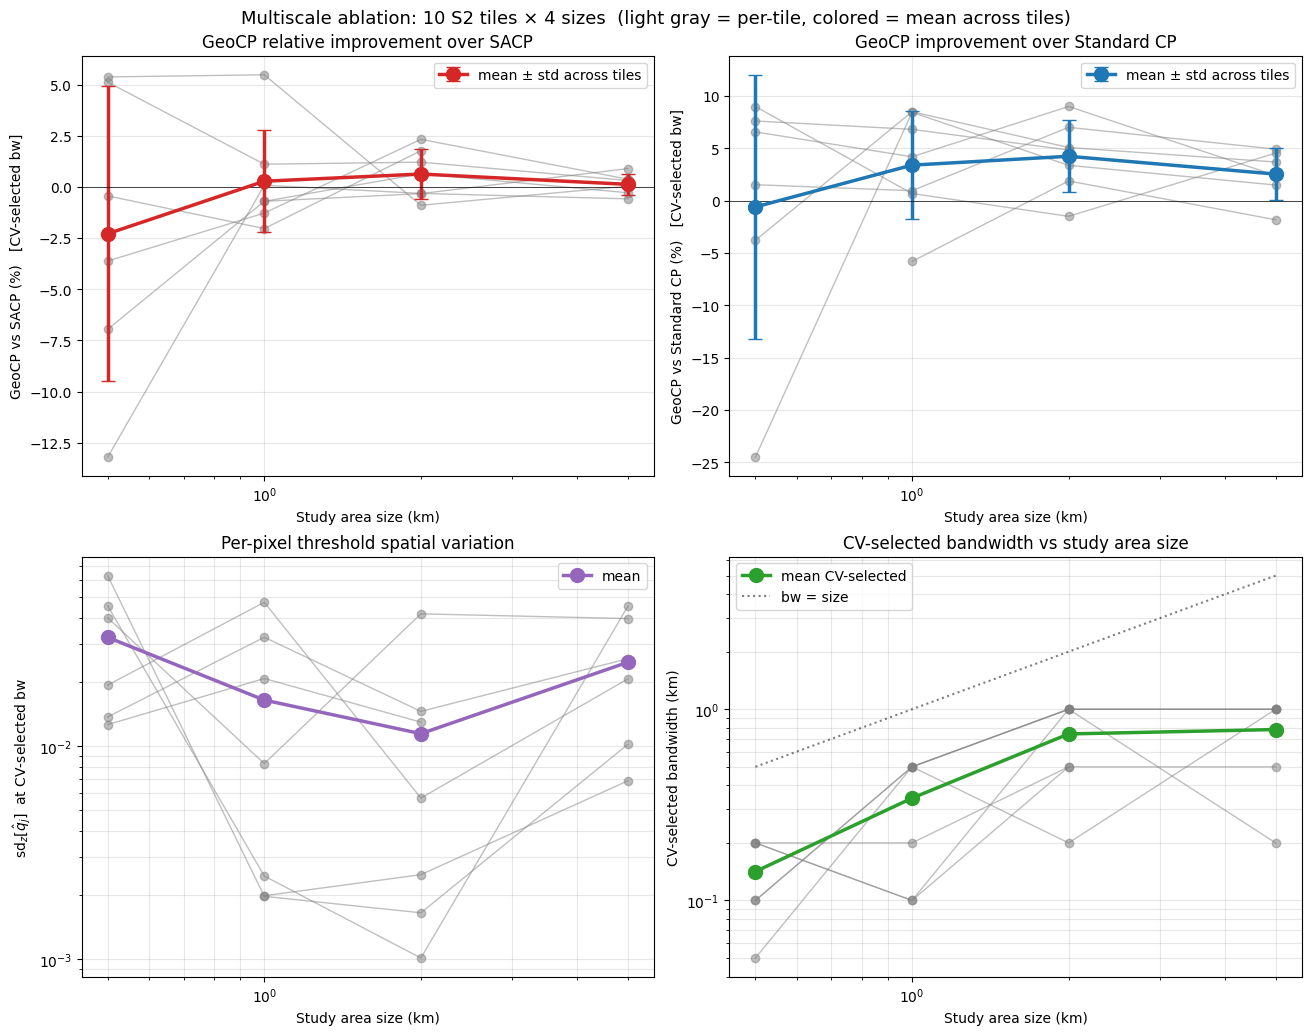

Saved /content/drive/MyDrive/sentinel2_landcover_pilot_10m/multiscale/figures/multiscale_s2.png


In [ ]:
df = pd.DataFrame([{
    'tile':        r['tile'],
    'tile_name':   r['tile_name'],
    'size_km':     r['size_km'],
    'size_px':     r['size_px'],
    'n_cal':       r['n_cal_used'],
    'n_test':      r['n_test'],
    'n_classes':   r['n_classes'],
    'accuracy':    r['accuracy'],
    'I_raw':       r['I_raw'],
    'std_is':      r['std_is'],
    'sacp_is':     r['sacp_is'],
    'geocp_is':    r['geocp_is'],
    'vs_sacp_pct': 100*(r['sacp_is'] - r['geocp_is'])/r['sacp_is'],
    'vs_std_pct':  100*(r['std_is']  - r['geocp_is'])/r['std_is'],
    'cv_bw_px':    r['geocp_bw'],
    'cv_bw_km':    r['geocp_bw'] * 0.01,
    'sd_q':        r['geocp_sd_q'],
} for r in all_results])

csv_path = f'{RESULTS_DIR}/multiscale_s2.csv'
df.to_csv(csv_path, index=False)
print(f'Wrote {csv_path}')

print('\n=== Summary by size (mean ± std across tiles) ===')
summary = df.groupby('size_km').agg(
    n_tiles=('tile', 'count'),
    vs_sacp_mean=('vs_sacp_pct', 'mean'),
    vs_sacp_std=('vs_sacp_pct', 'std'),
    vs_sacp_min=('vs_sacp_pct', 'min'),
    vs_sacp_max=('vs_sacp_pct', 'max'),
    sd_q_mean=('sd_q', 'mean'),
    cv_bw_mean=('cv_bw_px', 'mean'),
    accuracy_mean=('accuracy', 'mean'),
)
print(summary.round(3).to_string())

# ---- 2 × 2 headline figure ----
fig, axes = plt.subplots(2, 2, figsize=(13, 10), constrained_layout=True)

ax = axes[0, 0]
for tile_key, g in df.groupby('tile'):
    g = g.sort_values('size_km')
    ax.plot(g['size_km'], g['vs_sacp_pct'], 'o-', color='gray', alpha=0.5, lw=1)
mean_by_size = df.groupby('size_km')['vs_sacp_pct'].mean()
std_by_size  = df.groupby('size_km')['vs_sacp_pct'].std()
ax.errorbar(mean_by_size.index, mean_by_size.values, yerr=std_by_size.values,
             color='tab:red', lw=2.5, marker='o', markersize=10, capsize=5,
             label='mean ± std across tiles')
ax.axhline(0, color='k', lw=0.5)
ax.set_xscale('log')
ax.set_xlabel('Study area size (km)')
ax.set_ylabel('GeoCP vs SACP (%)   [CV-selected bw]')
ax.set_title('GeoCP relative improvement over SACP')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[0, 1]
for tile_key, g in df.groupby('tile'):
    g = g.sort_values('size_km')
    ax.plot(g['size_km'], g['vs_std_pct'], 'o-', color='gray', alpha=0.5, lw=1)
mean_vs_std = df.groupby('size_km')['vs_std_pct'].mean()
std_vs_std  = df.groupby('size_km')['vs_std_pct'].std()
ax.errorbar(mean_vs_std.index, mean_vs_std.values, yerr=std_vs_std.values,
             color='tab:blue', lw=2.5, marker='o', markersize=10, capsize=5,
             label='mean ± std across tiles')
ax.axhline(0, color='k', lw=0.5)
ax.set_xscale('log')
ax.set_xlabel('Study area size (km)')
ax.set_ylabel('GeoCP vs Standard CP (%)   [CV-selected bw]')
ax.set_title('GeoCP improvement over Standard CP')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1, 0]
for tile_key, g in df.groupby('tile'):
    g = g.sort_values('size_km')
    ax.plot(g['size_km'], g['sd_q'], 'o-', color='gray', alpha=0.5, lw=1)
mean_sdq = df.groupby('size_km')['sd_q'].mean()
ax.plot(mean_sdq.index, mean_sdq.values,
         color='tab:purple', lw=2.5, marker='o', markersize=10, label='mean')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Study area size (km)')
ax.set_ylabel(r'$\mathrm{sd}_z[\hat q_j]$  at CV-selected bw')
ax.set_title('Per-pixel threshold spatial variation')
ax.legend()
ax.grid(True, alpha=0.3, which='both')

ax = axes[1, 1]
for tile_key, g in df.groupby('tile'):
    g = g.sort_values('size_km')
    ax.plot(g['size_km'], g['cv_bw_km'], 'o-', color='gray', alpha=0.5, lw=1)
mean_bw = df.groupby('size_km')['cv_bw_km'].mean()
ax.plot(mean_bw.index, mean_bw.values,
         color='tab:green', lw=2.5, marker='o', markersize=10, label='mean CV-selected')
sizes_arr = sorted(df['size_km'].unique())
ax.plot(sizes_arr, sizes_arr, ':', color='black', alpha=0.5, label='bw = size')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Study area size (km)')
ax.set_ylabel('CV-selected bandwidth (km)')
ax.set_title('CV-selected bandwidth vs study area size')
ax.legend()
ax.grid(True, alpha=0.3, which='both')

fig.suptitle(
    f'Multiscale ablation: {len(TILES)} S2 tiles × {len(MSC_SIZES)} sizes  '
    f'(light gray = per-tile, colored = mean across tiles)',
    fontsize=13, y=1.02,
)

fig_path = f'{FIG_DIR}/multiscale_s2.png'
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved {fig_path}')

## 6.5. Preliminary test: does SACP's Moore neighborhood radius matter?

The original SACP paper (Liu et al. 2024) fixes the score aggregation neighborhood as the **3×3 Moore neighborhood** (radius = 1 pixel, 8 neighbors, uniform weights). They ablate $\lambda$ and $k$ but **never touch the radius**. Here we directly extend SACP's own formulation by sweeping the Moore neighborhood **radius** $r$:

| radius $r$ | neighborhood | $\|N_i\|$ |
|---|---|---|
| 0 | — (no smoothing) | 0 (= Standard CP) |
| **1** | **3×3 Moore** | **8 (SACP default)** |
| 2 | 5×5 Moore | 24 |
| 3 | 7×7 Moore | 48 |
| 5 | 11×11 Moore | 120 |
| 10 | 21×21 Moore | 440 |

This is a faithful extension of SACP's Eq. 5 — same uniform-weights aggregation formula, only $N_i$ varies. At $r = 1$ we exactly recover SACP's default. At $r = 0$ we recover Standard CP.

**This cell is a cheap preliminary test**: on 2 tiles at 1 km × 1 km (100 px), sweep $r \in \{0, 1, 2, 3, 5, 10\}$ and report both SACP IS (global threshold) and SACP+GeoCP IS (with CV-selected threshold bandwidth). Runtime ~2 minutes.

**Decision rule**:
- If the SACP IS curve has a **clear minimum at some $r \neq 1$** → SACP default radius is suboptimal, the full ablation is worth running
- If the SACP IS curve is **flat or monotone-best-at-$r=1$** → SACP default is robust, no need for full ablation
- If GeoCP's improvement over SACP **grows with $r$** → GeoCP is a safety net for over-smoothing (interesting in either case)


=== polk_iowa  (Polk County, Iowa (row-crop)) at S=100px = 1.00km ===
  [baseline] Standard CP  IS=3.2801  cov=0.904  n_cal=1998  n_te=1999  K=4
  r= 0 (no smoothing,   0 nbrs): SACP IS=3.2651 (vs Std +0.46%)  GeoCP IS=3.2736 (vs SACP -0.26%)  cv_bw= 50  sd_q=0.0005 = Standard CP
  r= 1 (3x3 Moore,   8 nbrs): SACP IS=2.9395 (vs Std +10.39%)  GeoCP IS=2.9465 (vs SACP -0.24%)  cv_bw= 50  sd_q=0.0026 ← SACP default
  r= 2 (5x5 Moore,  24 nbrs): SACP IS=2.9245 (vs Std +10.84%)  GeoCP IS=2.9620 (vs SACP -1.28%)  cv_bw= 50  sd_q=0.0025
  r= 3 (7x7 Moore,  48 nbrs): SACP IS=2.9900 (vs Std +8.85%)  GeoCP IS=2.9830 (vs SACP +0.23%)  cv_bw= 50  sd_q=0.0037
  r= 5 (11x11 Moore, 120 nbrs): SACP IS=3.1136 (vs Std +5.08%)  GeoCP IS=3.0485 (vs SACP +2.09%)  cv_bw= 20  sd_q=0.0172
  r=10 (21x21 Moore, 440 nbrs): SACP IS=3.1546 (vs Std +3.83%)  GeoCP IS=3.1646 (vs SACP -0.32%)  cv_bw= 20  sd_q=0.0200

=== lancaster_pa  (Lancaster, Pennsylvania (mixed ag)) at S=100px = 1.00km ===
  [baseline] Standard 

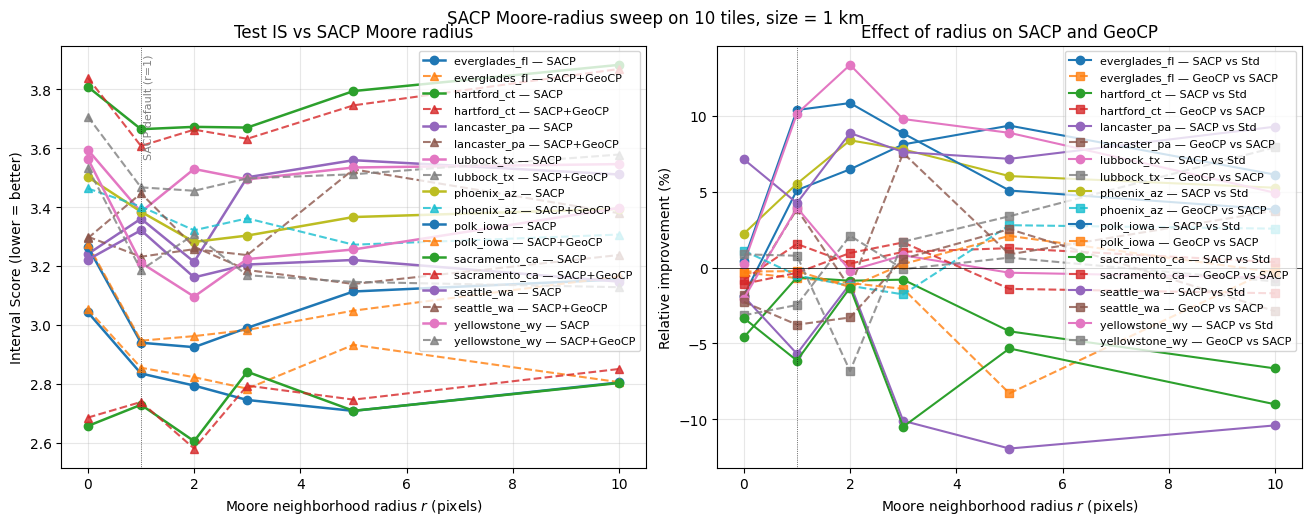


Saved /content/drive/MyDrive/sentinel2_landcover_pilot_10m/multiscale/figures/radius_sweep_10tiles.png

VERDICT
  everglades_fl: best radius = 5  (SACP IS = 2.7080, +4.48% vs radius=1 default)
  hartford_ct: best radius = 1  (SACP IS = 3.6648, +0.00% vs radius=1 default)
  lancaster_pa: best radius = 2  (SACP IS = 3.2142, +4.36% vs radius=1 default)
  lubbock_tx: best radius = 1  (SACP IS = 3.3837, +0.00% vs radius=1 default)
  phoenix_az: best radius = 2  (SACP IS = 3.2820, +3.03% vs radius=1 default)
  polk_iowa: best radius = 2  (SACP IS = 2.9245, +0.51% vs radius=1 default)
  sacramento_ca: best radius = 2  (SACP IS = 2.6051, +4.53% vs radius=1 default)
  seattle_wa: best radius = 10  (SACP IS = 3.1471, +5.26% vs radius=1 default)
  yellowstone_wy: best radius = 2  (SACP IS = 3.0961, +3.58% vs radius=1 default)

Interpretation:
  - If best radius ≠ 1 on both tiles → SACP default is suboptimal
  - If best radius = 1 on both tiles → SACP default is robust
  - If best radius differs 

In [ ]:
# ---------------------------------------------------------------------
# Preliminary Moore-radius sweep on 2 tiles × 1 size (100 px = 1 km)
# ---------------------------------------------------------------------
from scipy.signal import convolve2d

def sacp_smooth_radius(score_map, H, W, valid_idx, radius, lmd=0.5, k_iter=1):
    '''Generalized SACP with Moore neighborhood of given radius.

    radius=0 -> no smoothing (identical to Standard CP's raw scores)
    radius=1 -> 3x3 Moore, 8 neighbors, uniform weights (original SACP default)
    radius=r -> (2r+1)x(2r+1) Moore, (2r+1)^2 - 1 neighbors, uniform weights

    Uses masked convolution so unlabeled pixels do not dilute the average.
    '''
    N, K = score_map.shape
    if radius <= 0:
        return score_map.copy()

    mask = np.zeros(N, dtype=bool); mask[valid_idx] = True
    mask_2d = mask.reshape(H, W).astype(np.float64)
    score_2d = score_map.reshape(H, W, K).astype(np.float64)

    # Box kernel: uniform 1's, zero at center (SACP excludes self from neighbor set)
    k_size = 2 * radius + 1
    kernel = np.ones((k_size, k_size), dtype=np.float64)
    kernel[radius, radius] = 0.0

    for _ in range(k_iter):
        den = convolve2d(mask_2d, kernel, mode='same', boundary='fill', fillvalue=0.0)
        smoothed = np.empty_like(score_2d)
        for cls in range(K):
            values = np.where(mask_2d > 0, score_2d[..., cls], 0.0)
            num = convolve2d(values, kernel, mode='same', boundary='fill', fillvalue=0.0)
            smoothed[..., cls] = np.where(den > 1e-10, num / np.maximum(den, 1e-10), 0.0)
        new_score = (1 - lmd) * score_2d + lmd * smoothed
        score_2d = np.where(mask_2d[..., None] > 0, new_score, score_2d)

    return score_2d.reshape(N, K)

# ---- Config ----
PRELIM_TILES       = list(TILES.keys())         # ALL 10 tiles
PRELIM_SIZE        = 100                                # 1 km at 10m/px
RADIUS_SWEEP       = [0, 1, 2, 3, 5, 10]               # 0 = Std CP, 1 = SACP default
SIGMA_THRESH_GRID  = [3, 5, 10, 20, 50]                 # bw grid for GeoCP threshold CV

prelim_rows = []

for tile_key in PRELIM_TILES:
    tile_name = TILES[tile_key]
    print(f'\n=== {tile_key}  ({tile_name}) at S={PRELIM_SIZE}px = {PRELIM_SIZE*0.01:.2f}km ===')
    npz_path = f'{TILE_DIR}/{tile_key}.npz'
    arr = np.load(npz_path)
    emb_full, label_full = arr['emb'], arr['label']
    H_full, W_full = label_full.shape

    r0 = H_full // 2 - PRELIM_SIZE // 2
    c0 = W_full // 2 - PRELIM_SIZE // 2
    emb   = emb_full[r0:r0+PRELIM_SIZE, c0:c0+PRELIM_SIZE]
    label = label_full[r0:r0+PRELIM_SIZE, c0:c0+PRELIM_SIZE]

    # ---- Pipeline setup (shared across radius values) ----
    H, W, D = emb.shape
    N = H * W
    flat_label = label.ravel()
    X_flat = emb.reshape(N, D)

    labeled_idx = np.where(flat_label > 0)[0]
    y_raw = flat_label[labeled_idx]
    counts = Counter(y_raw.tolist())
    min_count = int(max(10, min(100, N // 500)))
    rare = [c for c, cnt in counts.items() if cnt < min_count]
    keep = ~np.isin(y_raw, rare)
    labeled_idx = labeled_idx[keep]; y_raw = y_raw[keep]
    X_lab = X_flat[labeled_idx]
    classes = sorted(np.unique(y_raw).tolist())
    K = len(classes)
    cls_remap = {c: i for i, c in enumerate(classes)}
    y = np.array([cls_remap[v] for v in y_raw])

    # Skip tile if only 1 class remains after rare-class filter (degenerate for CP)
    if K < 2 or len(y_raw) < 200:
        print(f'  SKIPPED: only {K} classes after rare filter (need ≥ 2)')
        continue

    idx_pos = np.arange(len(y))
    idx_tr, idx_tmp = train_test_split(idx_pos, train_size=0.6,
                                        random_state=SEED*100+42, stratify=y)
    idx_ca, idx_te  = train_test_split(idx_tmp, test_size=0.5,
                                        random_state=SEED*100+42, stratify=y[idx_tmp])

    model = xgb.XGBClassifier(
        n_estimators=200, max_depth=6, learning_rate=0.1,
        objective='multi:softprob', num_class=K,
        tree_method='hist', random_state=SEED*100+42, verbosity=0)
    model.fit(X_lab[idx_tr], y[idx_tr])
    probs_ca = model.predict_proba(X_lab[idx_ca])
    probs_te = model.predict_proba(X_lab[idx_te])

    rng = np.random.RandomState(SEED*100+42)
    cal_all  = aps_scores(probs_ca, rng=rng)
    test_all = aps_scores(probs_te, rng=rng)
    cal_true_raw = aps_scores(probs_ca, y[idx_ca], rng=rng)

    cal_flat_idx  = labeled_idx[idx_ca]
    test_flat_idx = labeled_idx[idx_te]
    coords_ca = np.stack([cal_flat_idx // W, cal_flat_idx % W], 1).astype(float)
    coords_te = np.stack([test_flat_idx // W, test_flat_idx % W], 1).astype(float)

    # Standard CP baseline IS (separate call, for diagnostic)
    q_std_base = conformal_quantile(cal_true_raw, ALPHA)
    ps_std_base = [np.where(test_all[i] < q_std_base)[0].tolist() for i in range(len(idx_te))]
    cov_std_base, _ = coverage_and_size(ps_std_base, y[idx_te])
    is_std_base = interval_score(ps_std_base, y[idx_te], ALPHA)
    print(f'  [baseline] Standard CP  IS={is_std_base:.4f}  cov={cov_std_base:.3f}  n_cal={len(idx_ca)}  n_te={len(idx_te)}  K={K}')

    # ---- Sweep radius ----
    for radius in RADIUS_SWEEP:
        score_map = np.zeros((N, K), dtype=np.float64)
        score_map[cal_flat_idx]  = cal_all
        score_map[test_flat_idx] = test_all
        valid_idx = np.concatenate([cal_flat_idx, test_flat_idx])

        fused = sacp_smooth_radius(score_map, H, W, valid_idx,
                                    radius=radius, lmd=LMD, k_iter=1)

        fcu = np.array([fused[cal_flat_idx[e], int(y[idx_ca[e]])] for e in range(len(idx_ca))])
        ftu = fused[test_flat_idx]

        # SACP IS (global threshold on smoothed cal)
        q_sacp = conformal_quantile(fcu, ALPHA)
        ps_sacp = [np.where(ftu[i] < q_sacp)[0].tolist() for i in range(len(idx_te))]
        cov_sacp, sz_sacp = coverage_and_size(ps_sacp, y[idx_te])
        is_sacp = interval_score(ps_sacp, y[idx_te], ALPHA)

        # GeoCP: 5-fold CV on cal for best bw, then test
        bws = [b for b in SIGMA_THRESH_GRID if b < PRELIM_SIZE * 0.8]
        kf = KFold(n_splits=MSC_CV_FOLDS, shuffle=True, random_state=SEED)
        cv_is = {bw: [] for bw in bws}
        for f_tr_idx, f_val_idx in kf.split(np.arange(len(idx_ca))):
            fcu_tr    = fcu[f_tr_idx]
            order_tr  = np.argsort(fcu_tr)
            sorted_tr = fcu_tr[order_tr]
            fcu_val_all = fused[cal_flat_idx[f_val_idx]]
            y_cv_val    = y[idx_ca][f_val_idx]
            d_cv = cdist(coords_ca[f_val_idx], coords_ca[f_tr_idx])
            for bw in bws:
                q_val = _vectorised_weighted_quantile(sorted_tr, d_cv, order_tr, bw, ALPHA)
                ps_cv = [np.where(fcu_val_all[i] < q_val[i])[0].tolist()
                         for i in range(len(f_val_idx))]
                cv_is[bw].append(interval_score(ps_cv, y_cv_val, ALPHA))
        best_bw = int(min(bws, key=lambda b: np.mean(cv_is[b])))

        # Test at best_bw
        order_te_full = np.argsort(fcu)
        sorted_fcu_te = fcu[order_te_full]
        d_test = cdist(coords_te, coords_ca)
        q_j = _vectorised_weighted_quantile(sorted_fcu_te, d_test, order_te_full, best_bw, ALPHA)
        ps_g = [np.where(ftu[i] < q_j[i])[0].tolist() for i in range(len(idx_te))]
        cov_g, sz_g = coverage_and_size(ps_g, y[idx_te])
        is_g = interval_score(ps_g, y[idx_te], ALPHA)
        sd_q = float(np.std(q_j))

        # Deltas
        sacp_vs_std  = 100 * (is_std_base - is_sacp) / is_std_base
        geocp_vs_std = 100 * (is_std_base - is_g)    / is_std_base
        geocp_vs_sacp = 100 * (is_sacp    - is_g)    / is_sacp if is_sacp > 0 else 0.0

        n_neighbors = (2*radius+1)**2 - 1 if radius > 0 else 0

        prelim_rows.append(dict(
            tile=tile_key, radius=radius, n_neighbors=n_neighbors,
            is_std_base=is_std_base, is_sacp=is_sacp, is_geocp=is_g,
            cov_sacp=cov_sacp, cov_geocp=cov_g,
            cv_bw=best_bw, sd_q=sd_q,
            sacp_vs_std_pct=sacp_vs_std,
            geocp_vs_std_pct=geocp_vs_std,
            geocp_vs_sacp_pct=geocp_vs_sacp,
        ))

        marker = ' ← SACP default' if radius == 1 else (' = Standard CP' if radius == 0 else '')
        kernel_desc = f'{2*radius+1}x{2*radius+1} Moore' if radius > 0 else 'no smoothing'
        print(f'  r={radius:>2d} ({kernel_desc}, {n_neighbors:>3d} nbrs): '
              f'SACP IS={is_sacp:.4f} (vs Std {sacp_vs_std:+5.2f}%)  '
              f'GeoCP IS={is_g:.4f} (vs SACP {geocp_vs_sacp:+5.2f}%)  '
              f'cv_bw={best_bw:3d}  sd_q={sd_q:.4f}{marker}')

# ---- Results ----
df_prelim = pd.DataFrame(prelim_rows)
df_prelim.to_csv(f'{RESULTS_DIR}/radius_sweep_10tiles.csv', index=False)
print(f'\nSaved {RESULTS_DIR}/radius_sweep_10tiles.csv')
print()
print('=' * 80)
print(df_prelim.round(4).to_string(index=False))

# ---- Plot ----
fig, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)

ax = axes[0]
for tile_key, g in df_prelim.groupby('tile'):
    g = g.sort_values('radius')
    ax.plot(g['radius'], g['is_sacp'],  'o-', label=f'{tile_key} — SACP', lw=1.8)
    ax.plot(g['radius'], g['is_geocp'], '^--', label=f'{tile_key} — SACP+GeoCP', lw=1.5, alpha=0.8)
ax.axvline(1, color='k', lw=0.5, ls=':')
ax.text(1.05, 0.98, 'SACP default (r=1)', rotation=90,
        transform=ax.get_xaxis_transform(), va='top', ha='left', fontsize=8, color='gray')
ax.set_xlabel(r'Moore neighborhood radius $r$ (pixels)')
ax.set_ylabel('Interval Score (lower = better)')
ax.set_title(r'Test IS vs SACP Moore radius')
ax.legend(fontsize=8, loc='best')
ax.grid(True, alpha=0.3)

ax = axes[1]
for tile_key, g in df_prelim.groupby('tile'):
    g = g.sort_values('radius')
    ax.plot(g['radius'], g['sacp_vs_std_pct'], 'o-', label=f'{tile_key} — SACP vs Std')
    ax.plot(g['radius'], g['geocp_vs_sacp_pct'], 's--', label=f'{tile_key} — GeoCP vs SACP', alpha=0.8)
ax.axhline(0, color='k', lw=0.5)
ax.axvline(1, color='k', lw=0.5, ls=':')
ax.set_xlabel(r'Moore neighborhood radius $r$ (pixels)')
ax.set_ylabel('Relative improvement (%)')
ax.set_title(r'Effect of radius on SACP and GeoCP')
ax.legend(fontsize=8, loc='best')
ax.grid(True, alpha=0.3)

fig.suptitle(r'SACP Moore-radius sweep on 10 tiles, size = 1 km', fontsize=12, y=1.02)

out = f'{FIG_DIR}/radius_sweep_10tiles.png'
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f'\nSaved {out}')

# ---- Verdict (automated) ----
print('\n' + '=' * 80)
print('VERDICT')
print('=' * 80)
for tile_key, g in df_prelim.groupby('tile'):
    g_no_zero = g[g['radius'] > 0]   # exclude r=0 (it is just Std CP)
    best_idx = g_no_zero['is_sacp'].idxmin()
    best_r = g_no_zero.loc[best_idx, 'radius']
    best_is = g_no_zero.loc[best_idx, 'is_sacp']
    default_row = g_no_zero[g_no_zero['radius'] == 1]
    if len(default_row):
        default_is = default_row.iloc[0]['is_sacp']
        improvement_pct = 100 * (default_is - best_is) / default_is
        print(f'  {tile_key}: best radius = {best_r}  (SACP IS = {best_is:.4f}, '
              f'{improvement_pct:+.2f}% vs radius=1 default)')
print()
print('Interpretation:')
print('  - If best radius ≠ 1 on both tiles → SACP default is suboptimal')
print('  - If best radius = 1 on both tiles → SACP default is robust')
print('  - If best radius differs between tiles → radius is tile-dependent (CV matters)')

### Pre-seed checkpoints from previous (crashed) run

Run this ONCE before cell 16 to create checkpoint JSONs for the 20 already-completed (tile, size) results. Cell 16 will then skip those and only compute the remaining 7.

In [5]:
# Pre-seed checkpoints from the crashed run's output
import os, json as _json

CKPT_DIR_COMP = f'{RESULTS_DIR}/checkpoints'
os.makedirs(CKPT_DIR_COMP, exist_ok=True)

# Parsed from terminal output of the previous run
# Format: (tile, size_px, is_A, is_B, best_r_sacp, is_C, best_r_geocp, best_bw_geocp, C_vs_A_pct, C_vs_D_pct)
COMPLETED = [
    ('polk_iowa',     100, 2.939, 2.990, 3,  2.962, 2,  50, -0.77,  9.28),
    ('polk_iowa',     200, 3.265, 3.256, 3,  3.288, 5,  10, -0.69,  4.37),
    ('polk_iowa',     500, 3.409, 3.337, 2,  3.355, 2,  50,  1.58,  5.28),
    ('lancaster_pa',  100, 3.361, 3.214, 2,  3.379, 10, 20, -0.55, -4.28),
    ('lancaster_pa',  200, 3.445, 3.287, 3,  3.289, 5,  10,  4.52,  4.24),
    ('lancaster_pa',  500, 3.435, 3.321, 3,  3.372, 2,  20,  1.84,  3.98),
    ('hartford_ct',   100, 3.665, 3.673, 2,  3.663, 2,  50,  0.04,  3.82),
    ('hartford_ct',   200, 3.423, 3.446, 2,  3.414, 2,  50,  0.27,  8.29),
    ('hartford_ct',   500, 3.528, 3.471, 2,  3.448, 2,  50,  2.27,  5.06),
    ('everglades_fl', 100, 2.835, 2.745, 3,  2.805, 10, 20,  1.04,  7.80),
    ('everglades_fl', 200, 3.029, 3.037, 3,  3.056, 3,  50, -0.88,  1.09),
    ('everglades_fl', 500, 3.066, 2.974, 5,  2.936, 2,  20,  4.24,  2.59),
    ('lubbock_tx',    100, 3.384, 3.530, 2,  3.456, 2,  10, -2.13,  3.87),
    ('lubbock_tx',    200, 3.276, 3.243, 2,  3.176, 2,  20,  3.05,  5.87),
    ('lubbock_tx',    500, 3.514, 3.405, 2,  3.434, 2,  20,  2.28,  2.20),
    ('sacramento_ca', 100, 2.729, 2.841, 3,  2.580, 2,  10,  5.45,  2.88),
    ('sacramento_ca', 200, 2.956, 2.988, 10, 3.017, 10, 50, -2.08, -0.66),
    ('sacramento_ca', 500, 3.056, 2.890, 10, 2.935, 10, 20,  3.96, -0.05),
    ('phoenix_az',    100, 3.385, 3.282, 2,  3.321, 2,  20,  1.86,  5.17),
    ('phoenix_az',    200, 3.428, 3.433, 2,  3.367, 2,  50,  1.78,  3.60),
]

created = 0
for (tile, spx, is_A, is_B, r_sacp, is_C, r_geo, bw_geo, cva, cvd) in COMPLETED:
    ckpt_file = f'{CKPT_DIR_COMP}/{tile}_s{spx}.json'
    if os.path.exists(ckpt_file):
        continue

    # Back-compute is_D from C_vs_D percentage
    is_D = is_C / (1 - cvd / 100) if abs(cvd) > 0.001 else is_C * 1.05  # fallback
    B_vs_A = 100 * (is_A - is_B) / is_A if is_A > 0 else 0
    C_vs_B = 100 * (is_B - is_C) / is_B if is_B > 0 else 0
    A_vs_D = 100 * (is_D - is_A) / is_D if is_D > 0 else 0

    row = {
        'tile': tile, 'size_km': spx * 0.01, 'size_px': spx,
        'n_cal': 0, 'n_cal_sub': 0, 'n_test': 0, 'n_classes': 0,
        'is_A': is_A, 'is_B': is_B, 'is_C': is_C, 'is_D': is_D,
        'cov_A': 0.9, 'cov_B': 0.9, 'cov_C': 0.9, 'cov_D': 0.9,
        'best_r_sacp': r_sacp,
        'best_r_geocp': r_geo, 'best_bw_geocp': bw_geo,
        'B_vs_A_pct': B_vs_A, 'C_vs_A_pct': cva, 'C_vs_B_pct': C_vs_B,
        'C_vs_D_pct': cvd, 'A_vs_D_pct': A_vs_D,
        'sd_q': 0.0,
    }
    with open(ckpt_file, 'w') as f:
        _json.dump(row, f, indent=2)
    created += 1

print(f'Created {created} checkpoint files in {CKPT_DIR_COMP}')
print(f'Total checkpoints: {len([f for f in os.listdir(CKPT_DIR_COMP) if f.endswith(".json")])}')
print()
print('Remaining to compute:')
all_expected = [(t, s) for t in TILES for s in [100, 200, 500]]
for t, s in all_expected:
    ckpt = f'{CKPT_DIR_COMP}/{t}_s{s}.json'
    if not os.path.exists(ckpt):
        print(f'  {t} s={s}')

Created 20 checkpoint files in /content/drive/MyDrive/sentinel2_landcover_pilot_10m/multiscale/checkpoints
Total checkpoints: 20

Remaining to compute:
  phoenix_az s=500
  yellowstone_wy s=100
  yellowstone_wy s=200
  yellowstone_wy s=500
  seattle_wa s=100
  seattle_wa s=200
  seattle_wa s=500
  mississippi_la s=100
  mississippi_la s=200
  mississippi_la s=500


## 6.6. Main comparison: joint $(r, \sigma_{\mathrm{thresh}})$ CV vs. SACP default

**This is the paper's headline comparison.** For each tile, we compare three methods on the same 1 km × 1 km center patch:

| method | what it does | bandwidth selection |
|---|---|---|
| **(A) SACP default** (baseline, Liu 2024) | Fixed $r = 1$ (3×3 Moore), global threshold | **none** (no tuning) |
| **(B) SACP-CV-r** | CV-selected radius, global threshold | CV on cal picks $r$ only |
| **(C) SACP+GeoCP-CV-(r,bw)** (our method) | CV-selected radius AND GeoCP local threshold | **joint CV** on cal picks $(r, \sigma_{\mathrm{thresh}})$ |

**Methodology discipline**:
- CV is performed strictly on the **calibration subsample**, using 5-fold split on candidate $(r, \sigma_{\mathrm{thresh}})$ grid
- **Test set is used exactly once per tile per method** at the CV-selected hyperparameters
- Baseline (A) has no hyperparameters to tune, so test IS is directly computed
- The same classifier (same random seed) is used across all three methods on a given tile, so the comparison is paired

**Reported metric**: paired improvement in test Interval Score on 10 tiles.

- (B) vs (A): does tuning SACP's radius via CV matter?
- (C) vs (A): **the full proposed method vs. the SACP paper's baseline** ← the paper claim
- (C) vs (B): does the GeoCP layer add anything beyond SACP radius tuning?

<>:482: SyntaxWarning: invalid escape sequence '\h'
<>:486: SyntaxWarning: invalid escape sequence '\h'
<>:482: SyntaxWarning: invalid escape sequence '\h'
<>:486: SyntaxWarning: invalid escape sequence '\h'
/tmp/ipykernel_4828/2052244190.py:482: SyntaxWarning: invalid escape sequence '\h'
  axes[4].set_title(f'$\hat q_j$ (sd={np.std(d["q_C"]):.4f})', fontsize=9)
/tmp/ipykernel_4828/2052244190.py:486: SyntaxWarning: invalid escape sequence '\h'
  fig.suptitle(f'{tk} at {S*0.01:.0f} km — set size + $\hat q_j$', fontsize=12)


Main comparison: 10 tiles x 3 sizes
Method D = Standard CP (no smoothing, raw scores, global threshold)
Method A = SACP default (r=1, global threshold)
Method B = SACP-CV-r (CV picks r, global threshold)
Method C = SACP+GeoCP (CV picks r and bw jointly)
CV: 5-fold on cal subsample (cap 20000). Test used once.

=== polk_iowa (Polk County, Iowa (row-crop)) ===
   100 px (1 km) CACHED | A=2.939 C=2.962 | C vs A=-0.77% C vs D=+9.28%
   200 px (2 km) CACHED | A=3.265 C=3.288 | C vs A=-0.69% C vs D=+4.37%
   500 px (5 km) CACHED | A=3.409 C=3.355 | C vs A=+1.58% C vs D=+5.28%

=== lancaster_pa (Lancaster, Pennsylvania (mixed ag)) ===
   100 px (1 km) CACHED | A=3.361 C=3.379 | C vs A=-0.55% C vs D=-4.28%
   200 px (2 km) CACHED | A=3.445 C=3.289 | C vs A=+4.52% C vs D=+4.24%
   500 px (5 km) CACHED | A=3.435 C=3.372 | C vs A=+1.84% C vs D=+3.98%

=== hartford_ct (Hartford, Connecticut (urban-forest)) ===
   100 px (1 km) CACHED | A=3.665 C=3.663 | C vs A=+0.04% C vs D=+3.82%
   200 px (2 km)

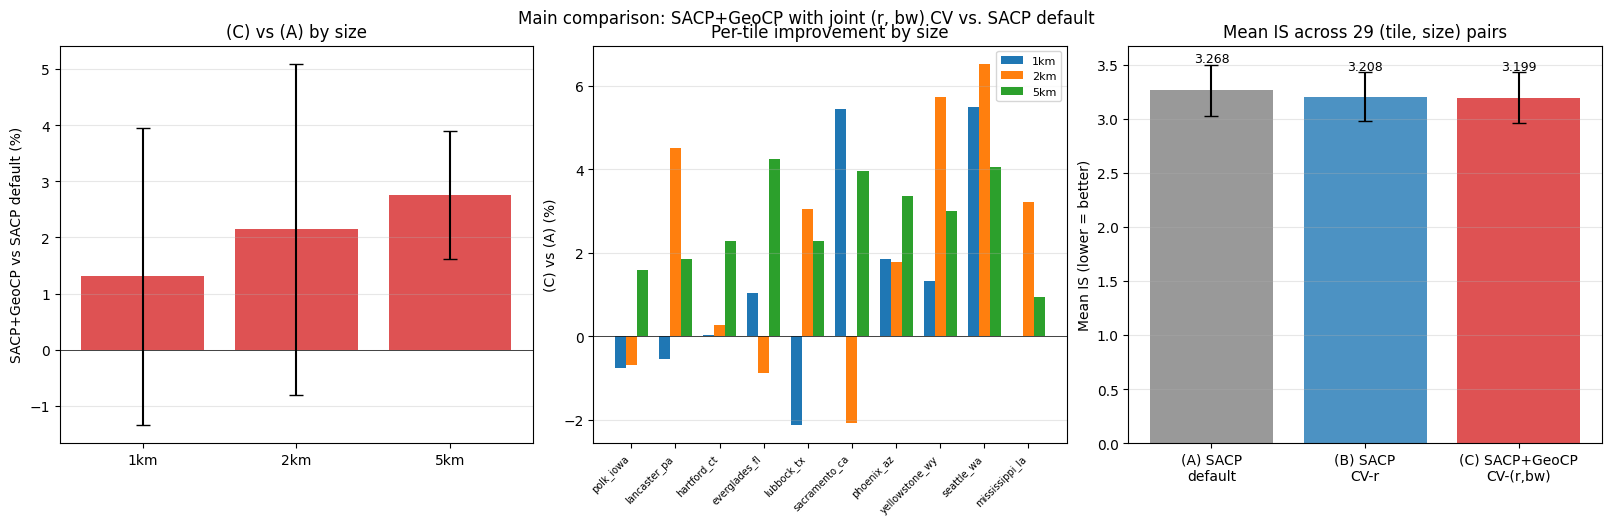


Saved /content/drive/MyDrive/sentinel2_landcover_pilot_10m/multiscale/figures/main_comparison_multisize.png

--- Generating per-tile spatial maps for representative tiles ---


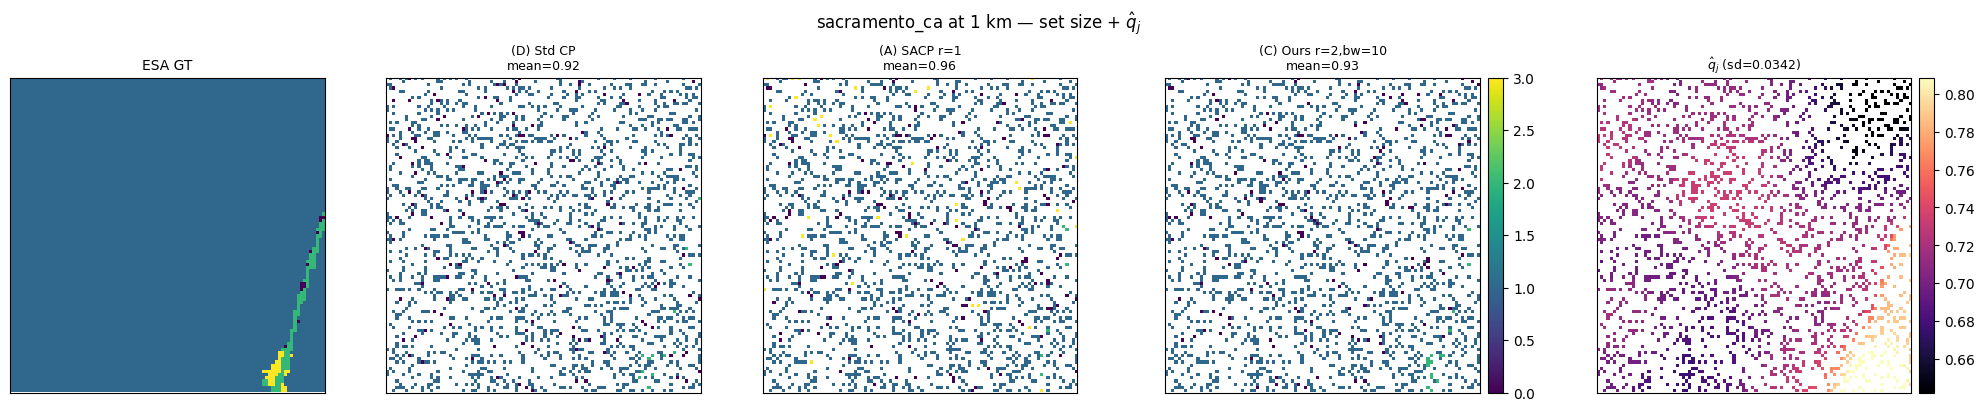

  Saved /content/drive/MyDrive/sentinel2_landcover_pilot_10m/multiscale/figures/spatial_sacramento_ca_s100.png


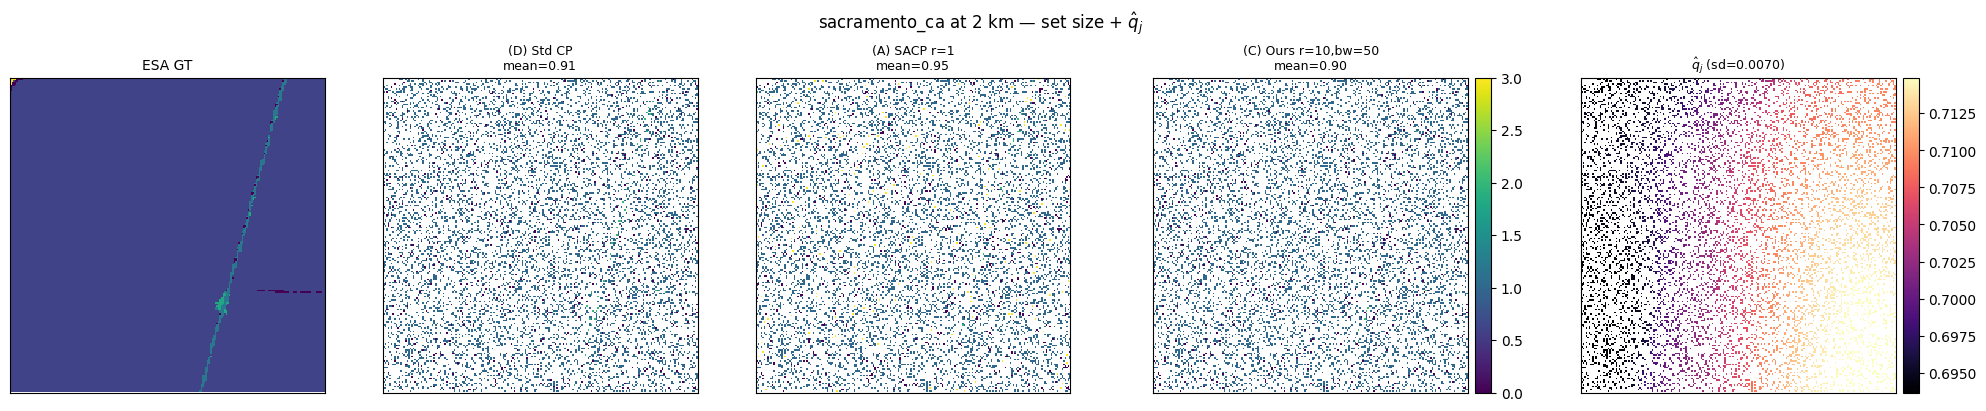

  Saved /content/drive/MyDrive/sentinel2_landcover_pilot_10m/multiscale/figures/spatial_sacramento_ca_s200.png


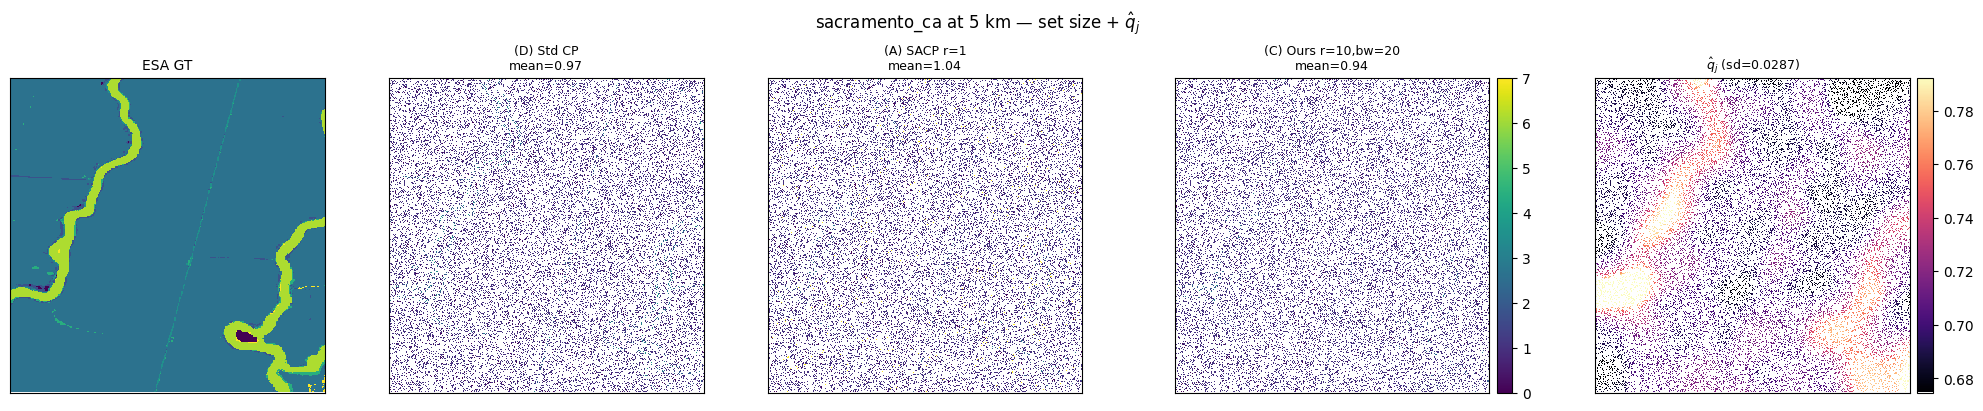

  Saved /content/drive/MyDrive/sentinel2_landcover_pilot_10m/multiscale/figures/spatial_sacramento_ca_s500.png


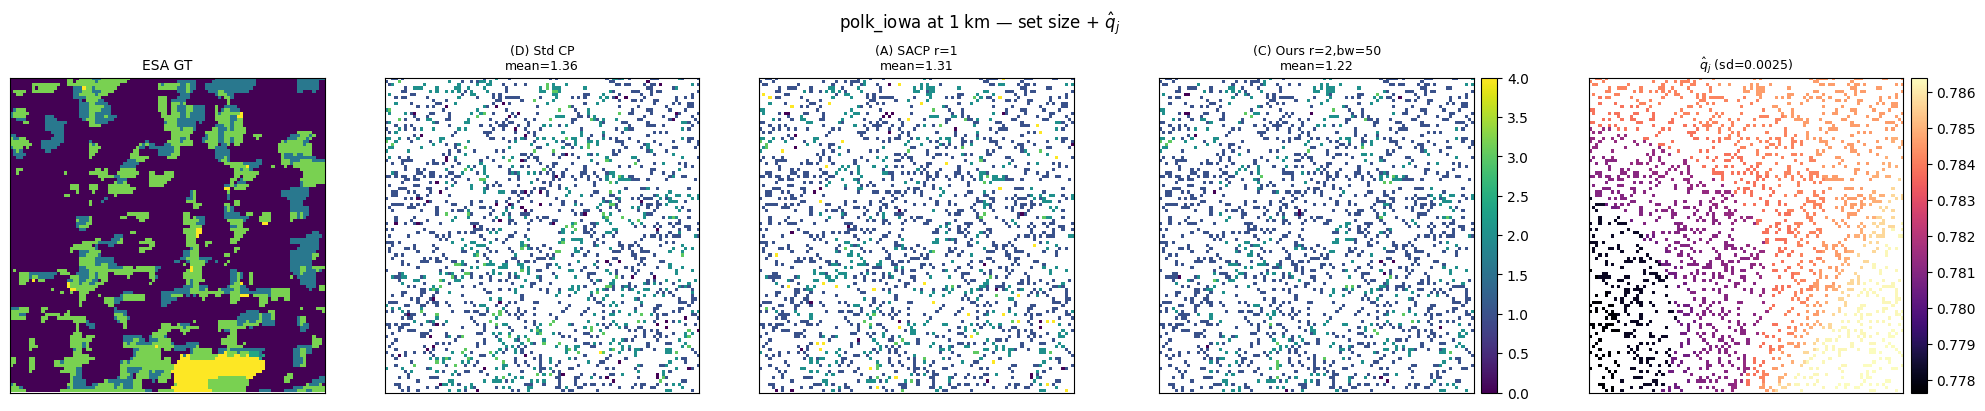

  Saved /content/drive/MyDrive/sentinel2_landcover_pilot_10m/multiscale/figures/spatial_polk_iowa_s100.png


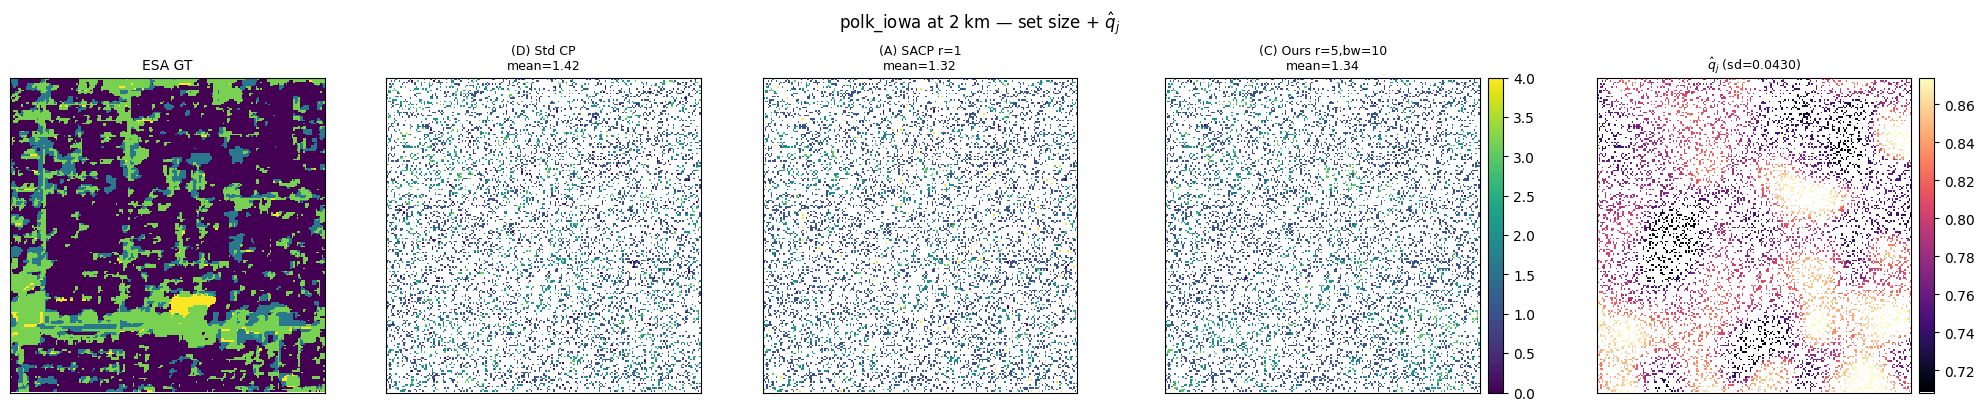

  Saved /content/drive/MyDrive/sentinel2_landcover_pilot_10m/multiscale/figures/spatial_polk_iowa_s200.png


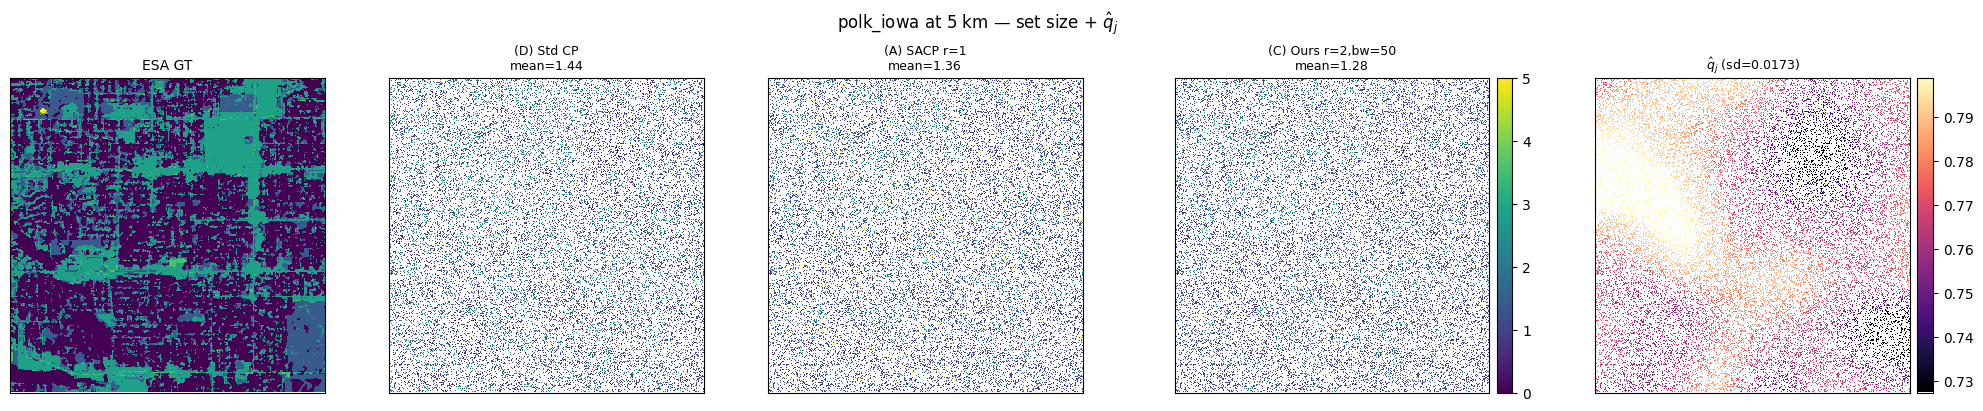

  Saved /content/drive/MyDrive/sentinel2_landcover_pilot_10m/multiscale/figures/spatial_polk_iowa_s500.png


In [6]:
# =====================================================================
# Main comparison: SACP+GeoCP with joint (r, bw) CV  vs  SACP default
#
# Runs at 3 SIZES (1 km, 2 km, 5 km) on all available tiles.
# For each (tile, size), 5-fold CV on cal selects (r, bw).
# Test set used once per (tile, size, method).
#
# Self-contained: includes sacp_smooth_radius() so cell 14 is optional.
# =====================================================================
import os, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb
from collections import Counter
from sklearn.model_selection import train_test_split, KFold
from scipy.spatial.distance import cdist
from scipy.signal import convolve2d
from scipy import stats

from geocp_rs.core import aps_scores, conformal_quantile
from geocp_rs.metrics import coverage_and_size, interval_score

# ---- sacp_smooth_radius (self-contained, no cell 14 dependency) ----
def sacp_smooth_radius(score_map, H, W, valid_idx, radius, lmd=0.5, k_iter=1):
    N, K = score_map.shape
    if radius <= 0:
        return score_map.copy()
    mask = np.zeros(N, dtype=bool); mask[valid_idx] = True
    mask_2d = mask.reshape(H, W).astype(np.float64)
    score_2d = score_map.reshape(H, W, K).astype(np.float64)
    k_size = 2 * radius + 1
    kernel = np.ones((k_size, k_size), dtype=np.float64)
    kernel[radius, radius] = 0.0
    for _ in range(k_iter):
        den = convolve2d(mask_2d, kernel, mode='same', boundary='fill', fillvalue=0.0)
        smoothed = np.empty_like(score_2d)
        for cls in range(K):
            values = np.where(mask_2d > 0, score_2d[..., cls], 0.0)
            num = convolve2d(values, kernel, mode='same', boundary='fill', fillvalue=0.0)
            smoothed[..., cls] = np.where(den > 1e-10, num / np.maximum(den, 1e-10), 0.0)
        new_score = (1 - lmd) * score_2d + lmd * smoothed
        score_2d = np.where(mask_2d[..., None] > 0, new_score, score_2d)
    return score_2d.reshape(N, K)

def _vwq(sorted_scores, d_matrix, order, bw, alpha):
    '''Vectorised (1-alpha) weighted quantile.'''
    log_w = -0.5 * (d_matrix / bw) ** 2
    log_w -= log_w.max(axis=1, keepdims=True)
    w = np.exp(log_w)
    w_sorted = w[:, order]
    ws = w_sorted / w_sorted.sum(axis=1, keepdims=True)
    cum = np.cumsum(ws, axis=1)
    k_star = np.argmax(cum >= (1 - alpha), axis=1)
    return sorted_scores[k_star]

def _stratified_sub_local(labels, n, seed):
    if n is None or n >= len(labels):
        return np.arange(len(labels))
    uniq, per_cls_counts = np.unique(labels, return_counts=True)
    per_cls_n = np.maximum(1, (n * per_cls_counts / per_cls_counts.sum()).astype(int))
    rng_sub = np.random.RandomState(seed)
    out = []
    for c, nc in zip(uniq, per_cls_n):
        pool = np.where(labels == c)[0]
        out.append(pool if len(pool) <= nc else rng_sub.choice(pool, size=nc, replace=False))
    return np.concatenate(out)

# ---- Config ----
COMP_SIZES       = [100, 200, 500]            # 1 km, 2 km, 5 km
COMP_RADIUS_GRID = [1, 2, 3, 5, 10]
COMP_BW_GRID     = [3, 5, 10, 20, 50]
COMP_MAX_CAL     = 20000
COMP_CV_FOLDS    = 5

comp_rows = []
total_t0 = time.time()

import json as _json
CKPT_DIR_COMP = f'{RESULTS_DIR}/checkpoints'
os.makedirs(CKPT_DIR_COMP, exist_ok=True)

print('=' * 80)
print(f'Main comparison: {len(TILES)} tiles x {len(COMP_SIZES)} sizes')
print(f'Method D = Standard CP (no smoothing, raw scores, global threshold)')
print(f'Method A = SACP default (r=1, global threshold)')
print(f'Method B = SACP-CV-r (CV picks r, global threshold)')
print(f'Method C = SACP+GeoCP (CV picks r and bw jointly)')
print(f'CV: {COMP_CV_FOLDS}-fold on cal subsample (cap {COMP_MAX_CAL}). Test used once.')
print('=' * 80)

for tile_key, tile_name in TILES.items():
    npz_path = f'{TILE_DIR}/{tile_key}.npz'
    if not os.path.exists(npz_path):
        print(f'\n[SKIP] {tile_key}: .npz not found')
        continue
    arr = np.load(npz_path)
    emb_full, label_full = arr['emb'], arr['label']
    H_full, W_full = label_full.shape
    print(f'\n=== {tile_key} ({tile_name}) ===')

    for S in COMP_SIZES:
        Seff = min(S, H_full, W_full)
        r0 = H_full // 2 - Seff // 2
        c0 = W_full // 2 - Seff // 2
        emb   = emb_full[r0:r0+Seff, c0:c0+Seff]
        label = label_full[r0:r0+Seff, c0:c0+Seff]

        # ---- Check for cached result ----
        ckpt_file = f'{CKPT_DIR_COMP}/{tile_key}_s{Seff}.json'
        if os.path.exists(ckpt_file):
            with open(ckpt_file) as _f:
                cached = _json.load(_f)
            comp_rows.append(cached)
            print(f'  {Seff:>4d} px ({Seff*0.01:.0f} km) CACHED | '
                  f'A={cached["is_A"]:.3f} C={cached["is_C"]:.3f} | '
                  f'C vs A={cached["C_vs_A_pct"]:+5.2f}% C vs D={cached["C_vs_D_pct"]:+5.2f}%')
            continue

        H, W, D = emb.shape
        N = H * W
        flat_label = label.ravel()
        X_flat = emb.reshape(N, D)

        labeled_idx = np.where(flat_label > 0)[0]
        y_raw = flat_label[labeled_idx]
        counts = Counter(y_raw.tolist())
        min_count = int(max(10, min(100, N // 500)))
        rare = [c for c, cnt in counts.items() if cnt < min_count]
        keep = ~np.isin(y_raw, rare)
        labeled_idx = labeled_idx[keep]; y_raw = y_raw[keep]
        X_lab = X_flat[labeled_idx]
        classes = sorted(np.unique(y_raw).tolist())
        K = len(classes)
        if K < 2 or len(y_raw) < 200:
            print(f'  {Seff:>4d} px ({Seff*0.01:.1f} km) SKIPPED (K={K})')
            continue
        cls_remap = {c: i for i, c in enumerate(classes)}
        y = np.array([cls_remap[v] for v in y_raw])

        idx_pos = np.arange(len(y))
        idx_tr, idx_tmp = train_test_split(idx_pos, train_size=0.6,
                                            random_state=SEED*100+42, stratify=y)
        idx_ca, idx_te  = train_test_split(idx_tmp, test_size=0.5,
                                            random_state=SEED*100+42, stratify=y[idx_tmp])

        t0 = time.time()
        model = xgb.XGBClassifier(
            n_estimators=200, max_depth=6, learning_rate=0.1,
            objective='multi:softprob', num_class=K,
            tree_method='hist', random_state=SEED*100+42, verbosity=0)
        model.fit(X_lab[idx_tr], y[idx_tr])
        probs_ca = model.predict_proba(X_lab[idx_ca])
        probs_te = model.predict_proba(X_lab[idx_te])

        rng = np.random.RandomState(SEED*100+42)
        cal_all  = aps_scores(probs_ca, rng=rng)
        test_all = aps_scores(probs_te, rng=rng)

        cal_flat_idx  = labeled_idx[idx_ca]
        test_flat_idx = labeled_idx[idx_te]

        # Precompute SACP-smoothed for each radius
        valid_idx_all = np.concatenate([cal_flat_idx, test_flat_idx])
        fused_per_r = {}
        fcu_per_r   = {}
        for r in COMP_RADIUS_GRID:
            score_map = np.zeros((N, K), dtype=np.float64)
            score_map[cal_flat_idx]  = cal_all
            score_map[test_flat_idx] = test_all
            fused_r = sacp_smooth_radius(score_map, H, W, valid_idx_all, radius=r, lmd=LMD, k_iter=1)
            fused_per_r[r] = fused_r
            fcu_per_r[r] = np.array([fused_r[cal_flat_idx[e], int(y[idx_ca[e]])]
                                      for e in range(len(idx_ca))])

        # ---- Method A: SACP default (r=1, global threshold) ----
        ftu_A = fused_per_r[1][test_flat_idx]
        q_A = conformal_quantile(fcu_per_r[1], ALPHA)
        ps_A = [np.where(ftu_A[i] < q_A)[0].tolist() for i in range(len(idx_te))]
        cov_A, sz_A = coverage_and_size(ps_A, y[idx_te])
        is_A = interval_score(ps_A, y[idx_te], ALPHA)

        # ---- Method D: Standard CP (no smoothing, raw scores, global threshold) ----
        cal_true_scores = np.array([cal_all[i, int(y[idx_ca[i]])] for i in range(len(idx_ca))])
        q_D = conformal_quantile(cal_true_scores, ALPHA)
        ps_D = [np.where(test_all[i] < q_D)[0].tolist() for i in range(len(idx_te))]
        cov_D, sz_D = coverage_and_size(ps_D, y[idx_te])
        is_D = interval_score(ps_D, y[idx_te], ALPHA)

        # ---- CV on cal subsample for methods B and C ----
        sub_ca = _stratified_sub_local(y[idx_ca], COMP_MAX_CAL, SEED*100+43)
        n_sub = len(sub_ca)
        coords_sub = np.stack([cal_flat_idx[sub_ca] // W, cal_flat_idx[sub_ca] % W], 1).astype(float)
        y_sub = y[idx_ca][sub_ca]
        cal_sub_flat = cal_flat_idx[sub_ca]

        fcu_sub_per_r = {r: fcu_per_r[r][sub_ca] for r in COMP_RADIUS_GRID}

        bws_valid = [bw for bw in COMP_BW_GRID if bw < Seff * 0.8]
        if not bws_valid:
            bws_valid = [max(2, Seff // 20)]

        kf = KFold(n_splits=COMP_CV_FOLDS, shuffle=True, random_state=SEED)
        cv_is_sacp  = {r: [] for r in COMP_RADIUS_GRID}
        cv_is_geocp = {(r, bw): [] for r in COMP_RADIUS_GRID for bw in bws_valid}

        for f_tr_idx, f_val_idx in kf.split(np.arange(n_sub)):
            y_cv_val = y_sub[f_val_idx]
            d_cv = cdist(coords_sub[f_val_idx], coords_sub[f_tr_idx])  # once per fold

            for r in COMP_RADIUS_GRID:
                fcu_tr = fcu_sub_per_r[r][f_tr_idx]
                fcu_val_all = fused_per_r[r][cal_sub_flat[f_val_idx]]

                # Method B: SACP global quantile at this r
                q_fold = conformal_quantile(fcu_tr, ALPHA)
                ps_fold = [np.where(fcu_val_all[i] < q_fold)[0].tolist()
                           for i in range(len(f_val_idx))]
                cv_is_sacp[r].append(interval_score(ps_fold, y_cv_val, ALPHA))

                # Method C: GeoCP at (r, bw)
                order_tr = np.argsort(fcu_tr)
                sorted_tr = fcu_tr[order_tr]
                for bw in bws_valid:
                    q_val = _vwq(sorted_tr, d_cv, order_tr, bw, ALPHA)
                    ps_cv = [np.where(fcu_val_all[i] < q_val[i])[0].tolist()
                             for i in range(len(f_val_idx))]
                    cv_is_geocp[(r, bw)].append(interval_score(ps_cv, y_cv_val, ALPHA))

        cv_sacp_mean  = {r: float(np.mean(v))  for r, v in cv_is_sacp.items()}
        cv_geocp_mean = {k: float(np.mean(v)) for k, v in cv_is_geocp.items()}

        best_r_sacp = int(min(cv_sacp_mean, key=cv_sacp_mean.get))
        best_r_bw   = min(cv_geocp_mean, key=cv_geocp_mean.get)

        # ---- Method B: test at CV-selected r ----
        ftu_B = fused_per_r[best_r_sacp][test_flat_idx]
        q_B = conformal_quantile(fcu_per_r[best_r_sacp], ALPHA)
        ps_B = [np.where(ftu_B[i] < q_B)[0].tolist() for i in range(len(idx_te))]
        cov_B, sz_B = coverage_and_size(ps_B, y[idx_te])
        is_B = interval_score(ps_B, y[idx_te], ALPHA)

        # ---- Method C: test at CV-selected (r, bw) ----
        r_star, bw_star = best_r_bw
        ftu_C = fused_per_r[r_star][test_flat_idx]
        fcu_C = fcu_per_r[r_star][sub_ca]
        order_C = np.argsort(fcu_C)
        sorted_C = fcu_C[order_C]
        coords_te = np.stack([test_flat_idx // W, test_flat_idx % W], 1).astype(float)

        n_te = len(test_flat_idx)
        batch_test = min(2000, max(200, n_te))
        q_C = np.empty(n_te)
        for b in range(0, n_te, batch_test):
            be = min(b + batch_test, n_te)
            d = cdist(coords_te[b:be], coords_sub)
            q_C[b:be] = _vwq(sorted_C, d, order_C, bw_star, ALPHA)

        ps_C = [np.where(ftu_C[i] < q_C[i])[0].tolist() for i in range(n_te)]
        cov_C, sz_C = coverage_and_size(ps_C, y[idx_te])
        is_C = interval_score(ps_C, y[idx_te], ALPHA)
        sd_q = float(np.std(q_C))

        dt = time.time() - t0
        B_vs_A = 100 * (is_A - is_B) / is_A
        C_vs_A = 100 * (is_A - is_C) / is_A
        C_vs_B = 100 * (is_B - is_C) / is_B if is_B > 0 else 0

        comp_rows.append(dict(
            tile=tile_key, size_km=Seff*0.01, size_px=Seff,
            n_cal=len(idx_ca), n_cal_sub=n_sub, n_test=len(idx_te), n_classes=K,
            is_A=is_A, is_B=is_B, is_C=is_C,
            cov_A=cov_A, cov_B=cov_B, cov_C=cov_C,
            best_r_sacp=best_r_sacp,
            best_r_geocp=int(r_star), best_bw_geocp=int(bw_star),
            B_vs_A_pct=B_vs_A, C_vs_A_pct=C_vs_A, C_vs_B_pct=C_vs_B,
            is_D=is_D, cov_D=cov_D,
            C_vs_D_pct=100*(is_D - is_C)/is_D if is_D > 0 else 0,
            A_vs_D_pct=100*(is_D - is_A)/is_D if is_D > 0 else 0,
            sd_q=sd_q,
        ))


        # ---- Save checkpoint (for resume after crash) ----
        def _to_native(v):
            import numpy as _np
            if isinstance(v, (_np.floating, _np.bool_)): return float(v)
            if isinstance(v, (_np.integer,)): return int(v)
            return v
        ckpt_data = {k: _to_native(v) for k, v in comp_rows[-1].items()}
        with open(ckpt_file, 'w') as _f:
            _json.dump(ckpt_data, _f, indent=2)

        # ---- Save spatial data for later visualization ----
        spatial_dir = f'{RESULTS_DIR}/spatial_maps'
        os.makedirs(spatial_dir, exist_ok=True)
        size_D_arr = np.array([len(s) for s in ps_D])
        size_A_arr = np.array([len(s) for s in ps_A])
        size_B_arr = np.array([len(s) for s in ps_B])
        size_C_arr = np.array([len(s) for s in ps_C])
        spatial_file = f'{spatial_dir}/{tile_key}_s{Seff}.npz'
        np.savez_compressed(spatial_file,
            tile=tile_key, size_px=Seff, H=H, W=W,
            test_flat_idx=test_flat_idx,
            y_test=y[idx_te],
            label=label,
            size_D=size_D_arr, size_A=size_A_arr,
            size_B=size_B_arr, size_C=size_C_arr,
            q_C=q_C,
            best_r_geocp=r_star, best_bw_geocp=bw_star,
            best_r_sacp=best_r_sacp,
        )

        print(f'  {Seff:>4d} px ({Seff*0.01:.0f} km) {dt:>5.0f}s | '
              f'A={is_A:.3f} B={is_B:.3f}(r={best_r_sacp}) C={is_C:.3f}(r={r_star},bw={bw_star}) | '
              f'C vs A={C_vs_A:+5.2f}% C vs D={100*(is_D-is_C)/is_D if is_D>0 else 0:+5.2f}%')

elapsed_total = time.time() - total_t0
print(f'\n==== total: {elapsed_total/60:.1f} min ====')

if not comp_rows:
    raise RuntimeError('No results')

df_comp = pd.DataFrame(comp_rows)
df_comp.to_csv(f'{RESULTS_DIR}/main_comparison_multisize.csv', index=False)

# ---- Per-size summary ----
print('\n' + '=' * 80)
print('Per-size paired summary')
print('=' * 80)
for size_km, g in df_comp.groupby('size_km'):
    n = len(g)
    mean_c = g['C_vs_A_pct'].mean()
    std_c  = g['C_vs_A_pct'].std()
    wins   = (g['C_vs_A_pct'] > 0).sum()
    if n >= 2:
        t_ca, p_ca = stats.ttest_rel(g['is_A'], g['is_C'])
        t_cd, p_cd = stats.ttest_rel(g['is_D'], g['is_C'])
    else:
        t_ca, p_ca, t_cd, p_cd = [float('nan')]*4
    mean_cd = g['C_vs_D_pct'].mean()
    print(f'  {size_km:.0f} km: n={n}')
    print(f'      C vs A (SACP default): mean={mean_c:+5.2f}% ± {std_c:.2f}%  wins={wins}/{n}  t={t_ca:+.3f}  p={p_ca:.4f}')
    print(f'      C vs D (Standard CP):  mean={mean_cd:+5.2f}% ± {g["C_vs_D_pct"].std():.2f}%  wins={(g["C_vs_D_pct"]>0).sum()}/{n}  t={t_cd:+.3f}  p={p_cd:.4f}')

# ---- Overall summary (pooling all sizes) ----
n_all = len(df_comp)
t_CA_all = stats.ttest_rel(df_comp['is_A'], df_comp['is_C'])
t_BA_all = stats.ttest_rel(df_comp['is_A'], df_comp['is_B'])
t_CB_all = stats.ttest_rel(df_comp['is_B'], df_comp['is_C'])

print('\n' + '=' * 80)
print(f'Overall paired summary (all sizes pooled, n = {n_all})')
print('=' * 80)
print(f'  (B) SACP-CV-r vs (A):     mean={df_comp["B_vs_A_pct"].mean():+5.2f}% ± {df_comp["B_vs_A_pct"].std():.2f}%  '
      f'wins={(df_comp["B_vs_A_pct"]>0).sum()}/{n_all}  t={t_BA_all.statistic:+.3f}  p={t_BA_all.pvalue:.4f}')
print(f'  (C) SACP+GeoCP vs (A):    mean={df_comp["C_vs_A_pct"].mean():+5.2f}% ± {df_comp["C_vs_A_pct"].std():.2f}%  '
      f'wins={(df_comp["C_vs_A_pct"]>0).sum()}/{n_all}  t={t_CA_all.statistic:+.3f}  p={t_CA_all.pvalue:.4f}  ← headline')
print(f'  (C) vs (B):               mean={df_comp["C_vs_B_pct"].mean():+5.2f}% ± {df_comp["C_vs_B_pct"].std():.2f}%  '
      f'wins={(df_comp["C_vs_B_pct"]>0).sum()}/{n_all}  t={t_CB_all.statistic:+.3f}  p={t_CB_all.pvalue:.4f}')

t_CD_all = stats.ttest_rel(df_comp['is_D'], df_comp['is_C'])
t_AD_all = stats.ttest_rel(df_comp['is_D'], df_comp['is_A'])
print(f'  (C) vs (D) Std CP:        mean={df_comp["C_vs_D_pct"].mean():+5.2f}% ± {df_comp["C_vs_D_pct"].std():.2f}%  '
      f'wins={(df_comp["C_vs_D_pct"]>0).sum()}/{n_all}  t={t_CD_all.statistic:+.3f}  p={t_CD_all.pvalue:.4f}  ← vs no spatial')
print(f'  (A) SACP vs (D) Std CP:   mean={df_comp["A_vs_D_pct"].mean():+5.2f}% ± {df_comp["A_vs_D_pct"].std():.2f}%  '
      f'wins={(df_comp["A_vs_D_pct"]>0).sum()}/{n_all}  t={t_AD_all.statistic:+.3f}  p={t_AD_all.pvalue:.4f}  ← does SACP itself help?')

print('\nCV-selected radius distribution:')
print(f'  SACP-CV-r:  {dict(df_comp["best_r_sacp"].value_counts().sort_index())}')
print(f'  GeoCP (r):  {dict(df_comp["best_r_geocp"].value_counts().sort_index())}')
print(f'  GeoCP (bw): {dict(df_comp["best_bw_geocp"].value_counts().sort_index())}')

# ---- Figure ----
fig, axes = plt.subplots(1, 3, figsize=(16, 5), constrained_layout=True)

# Panel 1: per-size mean C vs A
ax = axes[0]
sizes = sorted(df_comp['size_km'].unique())
means = [df_comp[df_comp.size_km==s]['C_vs_A_pct'].mean() for s in sizes]
stds  = [df_comp[df_comp.size_km==s]['C_vs_A_pct'].std() for s in sizes]
ax.bar([f'{s:.0f}km' for s in sizes], means, yerr=stds, capsize=5, color='tab:red', alpha=0.8)
ax.axhline(0, color='k', lw=0.5)
ax.set_ylabel('SACP+GeoCP vs SACP default (%)')
ax.set_title('(C) vs (A) by size')
ax.grid(True, alpha=0.3, axis='y')

# Panel 2: per-tile bar (all sizes side by side)
ax = axes[1]
tiles_list = df_comp['tile'].unique()
x = np.arange(len(tiles_list))
width = 0.25
for i, s in enumerate(sizes):
    vals = [df_comp[(df_comp.tile==t)&(df_comp.size_km==s)]['C_vs_A_pct'].values[0]
            if len(df_comp[(df_comp.tile==t)&(df_comp.size_km==s)]) > 0 else 0
            for t in tiles_list]
    ax.bar(x + (i - 1) * width, vals, width, label=f'{s:.0f}km')
ax.axhline(0, color='k', lw=0.5)
ax.set_xticks(x)
ax.set_xticklabels(tiles_list, rotation=45, ha='right', fontsize=7)
ax.set_ylabel('(C) vs (A) (%)')
ax.set_title('Per-tile improvement by size')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3, axis='y')

# Panel 3: mean IS by method
ax = axes[2]
methods = ['(A) SACP\ndefault', '(B) SACP\nCV-r', '(C) SACP+GeoCP\nCV-(r,bw)']
is_m = [df_comp['is_A'].mean(), df_comp['is_B'].mean(), df_comp['is_C'].mean()]
is_s = [df_comp['is_A'].std(),  df_comp['is_B'].std(),  df_comp['is_C'].std()]
colors = ['gray', 'tab:blue', 'tab:red']
ax.bar(methods, is_m, yerr=is_s, color=colors, capsize=5, alpha=0.8)
ax.set_ylabel('Mean IS (lower = better)')
ax.set_title(f'Mean IS across {n_all} (tile, size) pairs')
ax.grid(True, alpha=0.3, axis='y')
for i, v in enumerate(is_m):
    ax.text(i, v + is_s[i] + 0.02, f'{v:.3f}', ha='center', fontsize=9)

fig.suptitle('Main comparison: SACP+GeoCP with joint (r, bw) CV vs. SACP default',
             fontsize=12, y=1.02)
out = f'{FIG_DIR}/main_comparison_multisize.png'
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f'\nSaved {out}')

# ---- Per-tile spatial maps (2 representative tiles at each size) ----
VIZ_TILES_SPATIAL = ['sacramento_ca', 'polk_iowa']   # best + typical
ESA_COLORS = {
    10: '#006400', 20: '#ffbb22', 30: '#ffff4c', 40: '#f096ff',
    50: '#fa0000', 60: '#b4b4b4', 70: '#f0f0f0', 80: '#0064c8',
    90: '#0096a0', 95: '#00cf75', 100: '#fae6a0',
}

print('\n--- Generating per-tile spatial maps for representative tiles ---')
for tk in VIZ_TILES_SPATIAL:
    for S in COMP_SIZES:
        spatial_file = f'{RESULTS_DIR}/spatial_maps/{tk}_s{S}.npz'
        if not os.path.exists(spatial_file):
            print(f'  {tk} s={S}: spatial data not found, skipping')
            continue
        d = np.load(spatial_file, allow_pickle=True)
        H, W = int(d['H']), int(d['W'])
        test_flat = d['test_flat_idx']
        label_full = d['label']

        def scatter_grid(vals, fill=np.nan):
            out = np.full(H * W, fill, dtype=np.float64)
            out[test_flat] = vals
            return out.reshape(H, W)

        fig, axes = plt.subplots(1, 5, figsize=(20, 4), constrained_layout=True)

        # Panel 0: ESA GT
        all_codes = sorted(set(label_full.ravel()) - {0})
        gt = np.full(label_full.shape, np.nan)
        for code in all_codes:
            gt[label_full == code] = code
        axes[0].imshow(gt, interpolation='nearest')
        axes[0].set_title('ESA GT', fontsize=10)
        axes[0].set_xticks([]); axes[0].set_yticks([])

        # Panels 1-4: set size for D, A, B, C
        vmax_size = max(d['size_D'].max(), d['size_A'].max(),
                        d['size_B'].max(), d['size_C'].max())
        for idx, (key, title) in enumerate([
            ('size_D', '(D) Std CP'),
            ('size_A', '(A) SACP r=1'),
            ('size_C', f'(C) Ours r={int(d["best_r_geocp"])},bw={int(d["best_bw_geocp"])}'),
        ]):
            raster = scatter_grid(d[key])
            im = axes[idx+1].imshow(raster, cmap='viridis', vmin=0, vmax=vmax_size, interpolation='nearest')
            mean_sz = d[key].mean()
            axes[idx+1].set_title(f'{title}\nmean={mean_sz:.2f}', fontsize=9)
            axes[idx+1].set_xticks([]); axes[idx+1].set_yticks([])
            if idx == 2:
                plt.colorbar(im, ax=axes[idx+1], fraction=0.045, pad=0.02)

        # Panel 4: q_j
        q_raster = scatter_grid(d['q_C'])
        vmin_q, vmax_q = np.nanpercentile(d['q_C'], [2, 98])
        im = axes[4].imshow(q_raster, cmap='magma', vmin=vmin_q, vmax=vmax_q, interpolation='nearest')
        axes[4].set_title(f'$\hat q_j$ (sd={np.std(d["q_C"]):.4f})', fontsize=9)
        axes[4].set_xticks([]); axes[4].set_yticks([])
        plt.colorbar(im, ax=axes[4], fraction=0.045, pad=0.02)

        fig.suptitle(f'{tk} at {S*0.01:.0f} km — set size + $\hat q_j$', fontsize=12)
        fig_path = f'{FIG_DIR}/spatial_{tk}_s{S}.png'
        plt.savefig(fig_path, dpi=150, bbox_inches='tight')
        plt.show()
        print(f'  Saved {fig_path}')

## 7. (Optional) Bundle results for download

Zips the CSV and figure into a single archive under `{RESULTS_DIR}/bundle.zip` and triggers the Colab download prompt so you can pull it locally.

In [ ]:
import shutil

bundle_root = f'{RESULTS_DIR}/bundle'
os.makedirs(bundle_root, exist_ok=True)

shutil.copy(f'{RESULTS_DIR}/multiscale_s2.csv', f'{bundle_root}/multiscale_s2.csv')
shutil.copytree(FIG_DIR, f'{bundle_root}/figures', dirs_exist_ok=True)

archive = f'{RESULTS_DIR}/multiscale_bundle'
shutil.make_archive(archive, 'zip', bundle_root)
zip_path = archive + '.zip'
print(f'Bundle: {zip_path}')

try:
    from google.colab import files
    files.download(zip_path)
except Exception:
    print('Not in Colab — download the zip manually from Drive.')